# Avance 2 — Ingeniería de características para MLOps en un sistema de pricing B2B

**Equipo 46**  
**Proyecto:** Implementación de MLOps para versionado, monitoreo, observabilidad y decisión de retraining en un sistema de recomendación de precios B2B.

## Objetivo del notebook

Este notebook desarrolla la fase de **ingeniería de características** a partir del EDA del Avance 1, usando una versión académica y enmascarada del flujo de pricing.

El objetivo **no** es documentar ni reproducir la mecánica exacta del motor de pricing. El objetivo es construir variables y artefactos útiles para:

- validar entradas críticas del sistema;
- monitorear variables asociadas a demanda, precio y márgenes;
- separar datos usados para monitoreo del modelo vs. datos usados para artefactos de segmentación;
- representar bins/catálogos como artefactos de MLOps y gobernanza, no como reglas de decisión comercial;
- monitorear estabilidad de recomendaciones;
- alimentar drift detection, pruebas de contrato, versionado de artefactos y semáforo MLOps.

> **Nota de confidencialidad:** las variables, diagramas y cálculos se presentan como una abstracción académica sobre datos enmascarados. No se documentan reglas comerciales exactas, thresholds productivos, calibraciones internas ni lógica completa de decisión del motor.


## 1. Configuración del entorno

Se cargan librerías estándar para manipulación de datos, visualización, transformación, selección y extracción de características.

In [25]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

## 2. Carga de datos

Se distinguen tres fuentes lógicas:

1. **Dataset autorizado (`AUTH_INPUT_PATH`)**  
   Se usa para ingeniería de características relacionadas con el modelo: transformaciones de demanda/precio, validaciones de calidad, monitoreo de variables de entrada y unión con outputs recomendados.

2. **Dataset general (`GENERAL_INPUT_PATH`)**  
   Se usa para construir artefactos de segmentación y bins de negocio. En producción, esta fuente debe representar la población general de transacciones, no únicamente autorizaciones.

3. **Output de recomendaciones (`OUTPUT_PATH`)**  
   Se usa para ingeniería de características de monitoreo: estabilidad de recomendaciones, rangos de precio, señales de dispersión y semáforo.

> Nota operativa: si todavía no se cuenta con el dataset general completo, el notebook hace fallback al dataset autorizado y marca los catálogos como demostrativos. Cuando se tenga el archivo completo, solo hay que ajustar `GENERAL_INPUT_PATH` o guardar el archivo con alguno de los nombres esperados.


In [26]:
# Ajustar esta ruta si se ejecuta desde Google Colab / Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass

DIR_PATH = "/content/drive/MyDrive/Maestria/Yageo-MLOPS"

def first_existing_path(*candidate_paths, required=True):
    """Devuelve el primer archivo existente. Si required=False y no existe, devuelve None."""
    for path in candidate_paths:
        if path and os.path.exists(path):
            return path
    if required:
        raise FileNotFoundError(f"No se encontró ninguno de estos archivos: {candidate_paths}")
    return None

# 1) Dataset autorizado: fuente principal para monitoreo del modelo/recomendación.
AUTH_INPUT_PATH = first_existing_path(
    os.path.join(DIR_PATH, "masked_input_auth_dataset.csv"),
    os.path.join(DIR_PATH, "masked_input_dataset (1).csv"),
    os.path.join(DIR_PATH, "masked_input_dataset.csv")
)

# 2) Dataset general: fuente para artefactos de segmentación/catálogos.
GENERAL_INPUT_PATH = first_existing_path(
    os.path.join(DIR_PATH, "masked_general_input_dataset.csv"),
    os.path.join(DIR_PATH, "masked_input_complete_dataset.csv"),
    os.path.join(DIR_PATH, "masked_complete_input_dataset.csv"),
    os.path.join(DIR_PATH, "masked_all_transactions_dataset.csv"),
    os.path.join(DIR_PATH, "masked_input_general_dataset.csv"),
    required=False
)

# 3) Output de recomendaciones.
OUTPUT_PATH = first_existing_path(
    os.path.join(DIR_PATH, "masked_output_recommendations (1).csv"),
    os.path.join(DIR_PATH, "masked_output_recommendations.csv")
)

# Carga de datos
df_auth = pd.read_csv(AUTH_INPUT_PATH, low_memory=False)

# Si no hay dataset general, se usa auth como demostración para que el notebook corra completo.
USING_AUTH_AS_GENERAL_DEMO = GENERAL_INPUT_PATH is None
if USING_AUTH_AS_GENERAL_DEMO:
    GENERAL_INPUT_PATH = AUTH_INPUT_PATH
    df_general = df_auth.copy()
else:
    df_general = pd.read_csv(GENERAL_INPUT_PATH, low_memory=False)

df_output = pd.read_csv(OUTPUT_PATH, low_memory=False)

# Compatibilidad con versiones previas del notebook
df_input = df_auth.copy()

# Parseo de fechas cuando exista la columna
for df_name, df in [("auth", df_auth), ("general", df_general)]:
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(f"Auth input usado:    {os.path.basename(AUTH_INPUT_PATH)}")
print(f"General input usado: {os.path.basename(GENERAL_INPUT_PATH)}")
print(f"Output usado:        {os.path.basename(OUTPUT_PATH)}")
print(f"Auth dataset:        {df_auth.shape[0]:,} filas x {df_auth.shape[1]:,} columnas")
print(f"General dataset:     {df_general.shape[0]:,} filas x {df_general.shape[1]:,} columnas")
print(f"Output dataset:      {df_output.shape[0]:,} filas x {df_output.shape[1]:,} columnas")

if "date" in df_auth.columns and df_auth["date"].notna().any():
    print(f"Rango temporal auth:    {df_auth['date'].min().date()} a {df_auth['date'].max().date()}")
if "date" in df_general.columns and df_general["date"].notna().any():
    print(f"Rango temporal general: {df_general['date'].min().date()} a {df_general['date'].max().date()}")

if USING_AUTH_AS_GENERAL_DEMO:
    print("\nAVISO: no se encontró dataset general. Los catálogos de bins se construirán con auth como demostración académica.")
    print("Cuando se cargue el dataset general completo, los catálogos se recalcularán automáticamente con esa fuente.")

print("\nColumnas clave disponibles en auth/general:")
key_cols_to_check = [
    "kpn", "vpareadescription", "distysegment", "distributor_parentnumber",
    "custombusinessgroup", "hier_lev1", "quantity", "into_stock_price",
    "current_cost_auth", "rslpriceusd", "variablecostabb"
]
availability = pd.DataFrame({
    "column": key_cols_to_check,
    "auth_available": [c in df_auth.columns for c in key_cols_to_check],
    "general_available": [c in df_general.columns for c in key_cols_to_check]
})
display(availability)

print("\nColumnas output disponibles:")
print(df_output.columns.tolist())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Auth input usado:    masked_input_dataset (1).csv
General input usado: masked_input_complete_dataset.csv
Output usado:        masked_output_recommendations (1).csv
Auth dataset:        234,354 filas x 32 columnas
General dataset:     2,791,217 filas x 32 columnas
Output dataset:      8,314 filas x 40 columnas
Rango temporal auth:    2023-08-24 a 2025-08-24
Rango temporal general: 2023-08-24 a 2025-08-24

Columnas clave disponibles en auth/general:


,column,auth_available,general_available
0,kpn,True,True
1,vpareadescription,True,True
2,distysegment,True,True
3,distributor_parentnumber,True,True
4,custombusinessgroup,True,True
5,hier_lev1,True,True
6,quantity,True,True
7,into_stock_price,True,True
8,current_cost_auth,True,True
9,rslpriceusd,True,True



Columnas output disponibles:
['kpn', 'vpareadescription', 'distysegment', 'mean_elasticity', 'P0_PRICE', 'P20_PRICE', 'P50_PRICE', 'P85_PRICE', 'P100_PRICE', 'P0_RESALE', 'P20_RESALE', 'P50_RESALE', 'P85_RESALE', 'P100_RESALE', 'P0_QTY', 'P20_QTY', 'P35_QTY', 'P50_QTY', 'P65_QTY', 'P85_QTY', 'P100_QTY', 'P20', 'Min_P20_for_5pct_margin', 'P20_Adjusted_Min5pctMargin', 'P20_Was_Adjusted', 'P50', 'P85', 'q0', 'q0_method', 'q0_local_obs', 'Revenue_Aggressive', 'Revenue_Aggressive_QTY_OPT', 'More_Revenue', 'More_Revenue_QTY_OPT', 'Balanced', 'Balanced_QTY_OPT', 'More_Profit', 'More_Profit_QTY_OPT', 'Profit_Aggressive', 'Profit_Aggressive_QTY_OPT']


## 2.1 Separación de fuentes: modelo vs. artefactos de segmentación

La capa MLOps no debe mezclar el propósito de cada fuente:

| Fuente | Uso principal | Acción MLOps si cambia |
|---|---|---|
| Dataset autorizado | Salud estadística del modelo, demanda/precio y variables de entrada | Revisar, recalibrar o reentrenar si el cambio es persistente |
| Dataset general | Bins/catálogos y comportamiento agregado del canal | Recalcular catálogos, revisar reglas o validar con negocio |
| Output recomendado | Estabilidad de recomendaciones y señales de dispersión | Revisar estabilidad de outputs y riesgo operativo |

Por eso este notebook genera dos tipos de artefactos:

1. **Features del modelo**, calculadas con `df_auth`.
2. **Artefactos de segmentación**, calculados con `df_general`.

Esta separación mantiene el enfoque del proyecto en MLOps: versionar, monitorear y auditar tanto el modelo como los artefactos que afectan la interpretación operativa de sus recomendaciones.


## 3. Lógica analítica usada como contexto

Para construir features de monitoreo se asume que el sistema de pricing tiene dos bloques conceptuales:

### 3.1 Señales de demanda y precio

Se monitorean variables relacionadas con cantidad y precio interno, incluyendo transformaciones logarítmicas:

- `log(quantity)`
- `log(into_stock_price)`

Estas variables permiten evaluar estabilidad en la relación demanda-precio. En esta libreta **no se reentrena ni se recalibra el modelo**; solo se construyen features de validación y monitoreo.

### 3.2 Output de recomendación como caja negra

El motor de recomendación se trata como una **caja negra controlada**. El notebook no reproduce su lógica interna. Solo monitorea sus salidas mediante:

- percentiles de precio y cantidad;
- rangos de recomendación;
- señales de dispersión;
- flags de calidad;
- indicadores de estabilidad por segmento.

### 3.3 Granularidad de monitoreo

La granularidad se maneja de forma flexible:

- Si el output trae una llave operativa adicional, se conserva.
- Si no la trae, se mantiene la granularidad original del output y se agregan señales de composición desde el input.

Esto evita inventar una granularidad que el archivo de recomendaciones no tenga y mantiene el foco en MLOps, no en reconstruir la mecánica exacta del motor.


## 4. Copias de trabajo y validación del costo relevante

Se crean dos copias de trabajo:

- `input_fe`: datos autorizados usados para features del modelo y unión con recomendaciones.
- `catalog_fe`: datos generales usados para catálogos de bins de negocio.

La lógica general de `into_stock_price` prioriza fuentes de costo/precio interno en este orden:

1. `current_cost_master`
2. `current_cost_orders`
3. `current_cost_auth`

Sin embargo, para el dataset autorizado actual, el valor que importa validar contra `into_stock_price` es `current_cost_auth`. Esta validación no se trata como una imputación para modelar desde cero, sino como una **regla de calidad y contrato de datos** para MLOps.


In [27]:
input_fe = df_auth.copy()
catalog_fe = df_general.copy()
output_fe = df_output.copy()

# Regla de negocio para dataset autorizado: into_stock_price debe ser consistente con current_cost_auth.
required_auth_cols = ["current_cost_auth", "into_stock_price"]
missing_auth_cols = [c for c in required_auth_cols if c not in input_fe.columns]
if missing_auth_cols:
    raise ValueError(f"Faltan columnas requeridas para validar costo auth: {missing_auth_cols}")

input_fe["has_current_cost_auth"] = input_fe["current_cost_auth"].notna().astype(int)
input_fe["auth_cost_is_valid"] = (input_fe["current_cost_auth"] > 0).astype(int)
input_fe["into_stock_price_is_valid"] = (input_fe["into_stock_price"] > 0).astype(int)

# Diferencia absoluta y relativa entre into_stock_price y current_cost_auth
input_fe["auth_cost_abs_diff"] = (input_fe["into_stock_price"] - input_fe["current_cost_auth"]).abs()
input_fe["auth_cost_rel_diff"] = np.where(
    input_fe["current_cost_auth"] > 0,
    input_fe["auth_cost_abs_diff"] / input_fe["current_cost_auth"],
    np.nan
)

# Tolerancia pequeña por decimales / redondeos
AUTH_COST_TOLERANCE = 1e-6
input_fe["into_stock_matches_auth_cost"] = (input_fe["auth_cost_abs_diff"].fillna(np.inf) <= AUTH_COST_TOLERANCE).astype(int)

quality_summary = pd.DataFrame({
    "metric": [
        "auth_rows",
        "general_rows_for_catalogs",
        "using_auth_as_general_demo",
        "current_cost_auth_non_null_rate",
        "current_cost_auth_positive_rate",
        "into_stock_price_positive_rate",
        "into_stock_matches_auth_cost_rate",
        "auth_cost_abs_diff_median",
        "auth_cost_abs_diff_p95"
    ],
    "value": [
        len(input_fe),
        len(catalog_fe),
        USING_AUTH_AS_GENERAL_DEMO,
        input_fe["has_current_cost_auth"].mean(),
        input_fe["auth_cost_is_valid"].mean(),
        input_fe["into_stock_price_is_valid"].mean(),
        input_fe["into_stock_matches_auth_cost"].mean(),
        input_fe["auth_cost_abs_diff"].median(),
        input_fe["auth_cost_abs_diff"].quantile(0.95)
    ]
})

quality_summary


,metric,value
0,auth_rows,234354
1,general_rows_for_catalogs,2791217
2,using_auth_as_general_demo,False
3,current_cost_auth_non_null_rate,1.0
4,current_cost_auth_positive_rate,1.0
5,into_stock_price_positive_rate,1.0
6,into_stock_matches_auth_cost_rate,0.987493
7,auth_cost_abs_diff_median,0.0
8,auth_cost_abs_diff_p95,0.0


### Justificación MLOps

En este avance ya no se usa `current_cost_orders` como costo principal para features. Para el dataset actual, el chequeo crítico es que `into_stock_price` sea consistente con `current_cost_auth`. Esta validación puede convertirse en una prueba de contrato: si en una corrida futura el porcentaje de coincidencia baja, podría indicar cambio de fuente, corrupción de datos o mezcla de registros autorizados/no autorizados.

## 5. Features de demanda y precio

Estas características respetan el enfoque existente sin recalcular el modelo. Se calculan transformaciones logarítmicas sobre:

- `quantity`
- `into_stock_price`

También se crean señales de incertidumbre disponibles en el output o input, utilizadas para monitoreo y drift, no para modificar recomendaciones.


In [28]:
# Variables base de elasticidad
input_fe["log_quantity"] = np.where(input_fe["quantity"] > 0, np.log(input_fe["quantity"]), np.nan)
input_fe["log_into_stock_price"] = np.where(input_fe["into_stock_price"] > 0, np.log(input_fe["into_stock_price"]), np.nan)

# Revenue de reventa / venta observada, útil para ponderar drift por impacto financiero
input_fe["revenue"] = input_fe["rslpriceusd"] * input_fe["quantity"]
input_fe["log_revenue"] = np.where(input_fe["revenue"] > 0, np.log(input_fe["revenue"]), np.nan)

# Señales bayesianas de elasticidad
input_fe["elasticity_abs"] = input_fe["elasticity_mean"].abs()
input_fe["elasticity_hdi_width"] = input_fe["hdi_97%_elasticity"] - input_fe["hdi_3%_elasticity"]
input_fe["elasticity_uncertainty_ratio"] = np.where(
    input_fe["elasticity_abs"] > 0,
    input_fe["elasticity_sd"] / input_fe["elasticity_abs"],
    np.nan
)

elasticity_feature_summary = input_fe[[
    "quantity", "into_stock_price", "log_quantity", "log_into_stock_price",
    "elasticity_mean", "elasticity_sd", "elasticity_hdi_width", "elasticity_uncertainty_ratio"
]].describe(percentiles=[0.05, 0.5, 0.95]).T.round(4)

elasticity_feature_summary

,count,mean,std,min,5%,50%,95%,max
quantity,234354.0,400651.0525,1.370103e+06,12.0000,6000.0000,96000.0000,1.542262e+06,9.804000e+07
into_stock_price,234354.0,2.3574,1.618780e+01,0.0120,0.0249,0.1462,8.291200e+00,1.369119e+03
log_quantity,234354.0,11.4828,1.664100e+00,2.4849,8.6995,11.4721,1.424880e+01,1.840090e+01
log_into_stock_price,234354.0,-1.4245,1.898100e+00,-4.4228,-3.6915,-1.9228,2.115200e+00,7.221900e+00
elasticity_mean,234354.0,-2.4150,2.953900e+00,-17.5284,-7.3363,-2.3499,2.698000e+00,1.395440e+01
elasticity_sd,234354.0,0.5697,6.412000e-01,0.0770,0.1172,0.3422,2.063300e+00,6.219900e+00
elasticity_hdi_width,234354.0,2.1391,2.412600e+00,0.2817,0.4407,1.2869,7.734300e+00,2.353030e+01
elasticity_uncertainty_ratio,234354.0,1.0458,1.597130e+01,0.0234,0.0376,0.1274,2.224100e+00,1.928860e+03


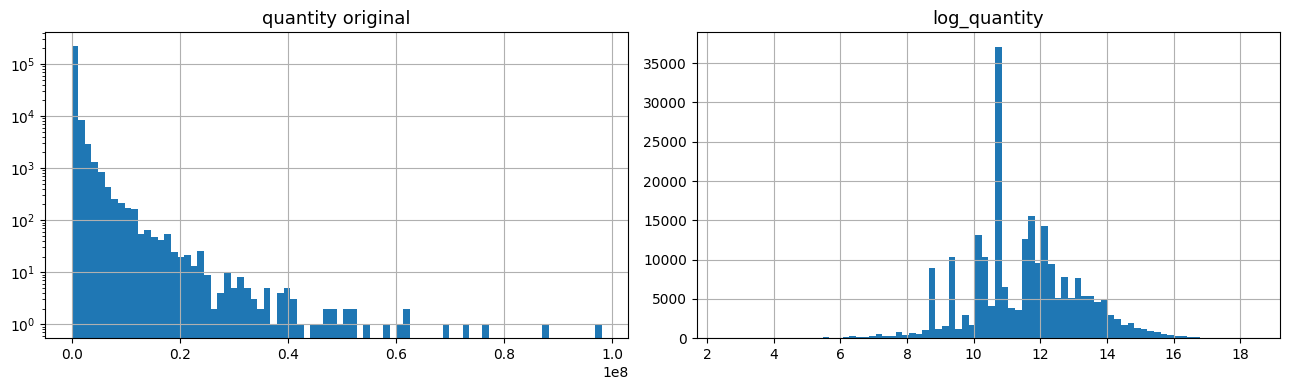

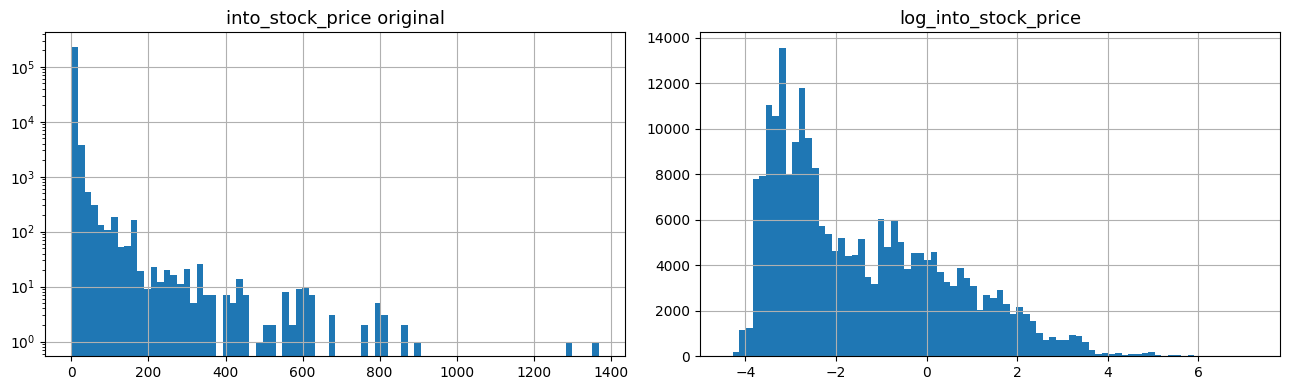

In [29]:
# Visualización de las transformaciones principales usadas para elasticidad
plot_pairs = [("quantity", "log_quantity"), ("into_stock_price", "log_into_stock_price")]

for raw_col, log_col in plot_pairs:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    input_fe[raw_col].dropna().hist(bins=80, ax=axes[0])
    axes[0].set_title(f"{raw_col} original")
    axes[0].set_yscale("log")
    input_fe[log_col].dropna().hist(bins=80, ax=axes[1])
    axes[1].set_title(f"{log_col}")
    plt.tight_layout()
    plt.show()

Las gráficas confirman que la transformación logarítmica reduce la asimetría extrema de `quantity` e `into_stock_price`. Esto no elimina la variabilidad natural del negocio, pero permite representar mejor las diferencias relativas entre segmentos y hace que las variables sean más adecuadas para el cálculo de elasticidad y para el monitoreo de drift.

Se observa que `elasticity_uncertainty_ratio` tiene valores máximos muy altos. Esto ocurre cuando `elasticity_abs` es cercano a cero y la desviación estándar relativa se vuelve inestable. Por esta razón, esta variable debe interpretarse como una señal de alerta y no como una métrica aislada. En futuras etapas MLOps podría aplicarse winsorización, clipping o una regla de control para evitar que valores extremos distorsionen el semáforo.

### Interpretación de las transformaciones de demanda/precio

Las variables `quantity` e `into_stock_price` presentan distribuciones sesgadas hacia la derecha. En su escala original, ambas concentran una gran cantidad de observaciones en valores bajos y muestran colas largas con valores extremos. Esto es consistente con datos transaccionales de pricing B2B.

Se aplicó una transformación logarítmica sobre `quantity` e `into_stock_price` porque facilita analizar diferencias relativas entre precio y demanda:

$$
\log(\text{quantity}) = \beta_0 + \beta_1 \log(\text{into\_stock\_price}) + \epsilon
$$

En un enfoque econométrico, la pendiente puede interpretarse como sensibilidad precio-demanda. En este proyecto, esa relación se usa como **contexto de monitoreo**, no como una reconstrucción del modelo productivo.

Desde el enfoque MLOps, estas transformaciones son relevantes porque permiten monitorear la estabilidad de variables base. Un cambio importante en la distribución de `log_quantity`, `log_into_stock_price` o señales de incertidumbre puede indicar drift en los datos autorizados y justificar una revisión, recalibración o eventual reentrenamiento.


## 6. Features de margen y negocio

Se generan variables económicas derivadas para monitoreo y segmentación:

- **Distributor margin:** margen observado del distribuidor respecto a la reventa.
- **Company margin sobre costo variable:** margen interno sobre `variablecostabb`.
- **Channel margin share:** proporción del margen de canal capturada por la compañía, usando una razón de margen.

Estas variables se calculan en ambas fuentes:

- En `input_fe` para monitorear los datos autorizados que alimentan el modelo.
- En `catalog_fe` para construir artefactos de segmentación con la población general.

> Para proteger confidencialidad, estas métricas se presentan como señales analíticas generales; no se documentan políticas comerciales ni thresholds productivos.


In [30]:
def add_business_margin_features(df: pd.DataFrame) -> pd.DataFrame:
    """Agrega variables de margen usadas por monitoreo y catálogos de negocio."""
    df = df.copy()

    required_cols = ["rslpriceusd", "into_stock_price", "variablecostabb"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas requeridas para features de margen: {missing}")

    # Margen del distribuidor: diferencia entre precio de reventa e into-stock price
    df["distributor_margin_usd"] = df["rslpriceusd"] - df["into_stock_price"]
    df["distributor_margin_pct"] = np.where(
        df["rslpriceusd"] > 0,
        df["distributor_margin_usd"] / df["rslpriceusd"],
        np.nan
    )

    # Margen de KEMET sobre costo variable
    df["kemet_margin_over_variable_cost"] = df["into_stock_price"] - df["variablecostabb"]
    df["kemet_margin_pct_of_into_stock"] = np.where(
        df["into_stock_price"] > 0,
        df["kemet_margin_over_variable_cost"] / df["into_stock_price"],
        np.nan
    )

    # Channel margin share = margen KEMET / margen total del canal
    channel_denominator = df["rslpriceusd"] - df["variablecostabb"]
    df["channel_margin_share"] = np.where(
        channel_denominator > 0,
        (df["into_stock_price"] - df["variablecostabb"]) / channel_denominator,
        np.nan
    )

    # Flags de calidad de negocio
    df["negative_distributor_margin_flag"] = (df["distributor_margin_usd"] < 0).astype(int)
    df["negative_kemet_variable_margin_flag"] = (df["kemet_margin_over_variable_cost"] < 0).astype(int)
    df["channel_margin_share_out_of_range_flag"] = (
        (df["channel_margin_share"] < 0) | (df["channel_margin_share"] > 1)
    ).astype(int)

    return df

input_fe = add_business_margin_features(input_fe)
catalog_fe = add_business_margin_features(catalog_fe)

margin_cols = [
    "distributor_margin_pct", "kemet_margin_pct_of_into_stock", "channel_margin_share",
    "negative_distributor_margin_flag", "negative_kemet_variable_margin_flag",
    "channel_margin_share_out_of_range_flag"
]

print("Resumen auth — variables de margen:")
display(input_fe[margin_cols].describe(percentiles=[0.01, 0.05, 0.33, 0.5, 0.66, 0.95, 0.99]).T)

print("Resumen general/catalog — variables de margen:")
display(catalog_fe[margin_cols].describe(percentiles=[0.01, 0.05, 0.33, 0.5, 0.66, 0.95, 0.99]).T)


Resumen auth — variables de margen:


,count,mean,std,min,1%,5%,33%,50%,66%,95%,99%,max
distributor_margin_pct,234354.0,0.184372,0.108697,0.000000,0.026923,0.043061,0.133180,0.171348,0.208340,0.400000,0.572180,0.985536
kemet_margin_pct_of_into_stock,234354.0,0.554539,0.179071,0.000113,0.108929,0.242000,0.482195,0.554150,0.625400,0.857889,0.937565,0.966637
channel_margin_share,234354.0,0.705281,0.159017,0.001330,0.155005,0.421774,0.663359,0.722892,0.778235,0.929329,0.960905,1.000000
negative_distributor_margin_flag,234354.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
negative_kemet_variable_margin_flag,234354.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
channel_margin_share_out_of_range_flag,234354.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Resumen general/catalog — variables de margen:


,count,mean,std,min,1%,5%,33%,50%,66%,95%,99%,max
distributor_margin_pct,2791217.0,0.522548,0.256178,0.000000,0.034335,0.095099,0.400000,0.565691,0.679487,0.883750,0.940247,0.999848
kemet_margin_pct_of_into_stock,2791217.0,0.699665,0.182022,0.000113,0.214023,0.365928,0.625522,0.727754,0.799091,0.948031,0.962725,0.966664
channel_margin_share,2791217.0,0.407529,0.250590,0.000068,0.033131,0.075041,0.243400,0.357414,0.502596,0.855910,0.947574,1.000000
negative_distributor_margin_flag,2791217.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
negative_kemet_variable_margin_flag,2791217.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
channel_margin_share_out_of_range_flag,2791217.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### Interpretación de features de margen y negocio

Las variables de margen permiten representar la estructura económica del canal y son relevantes tanto para monitoreo MLOps como para artefactos de segmentación.

Se calcularon tres señales principales:

- `distributor_margin_pct`: proporción del precio de reventa capturada por el distribuidor.
- `kemet_margin_pct_of_into_stock`: margen interno sobre costo variable, relativo al precio into-stock.
- `channel_margin_share`: proporción del margen total del canal capturada por la compañía, calculada como:

$$
\frac{\text{into\_stock\_price} - \text{variablecostabb}}
{\text{rslpriceusd} - \text{variablecostabb}}
$$

La comparación entre dataset autorizado y dataset general permite evaluar si la población usada para monitorear el modelo representa o no el comportamiento completo del canal.

Para preservar confidencialidad, el análisis se mantiene a nivel agregado y no documenta reglas comerciales, thresholds internos ni decisiones operativas específicas. En una etapa posterior, estas señales pueden usarse para pruebas de contrato, drift segmentado y semáforo MLOps.


## 7. Artefactos de segmentación y bins

El proceso MLOps separa dos conceptos:

1. **Catálogo:** define cortes y etiquetas a cierto nivel de agregación.
2. **Asignación:** cada registro o recomendación cae en una etiqueta según su valor observado.

En un entorno productivo, estos catálogos deben calcularse con el **dataset general de transacciones**, porque describen comportamiento amplio del canal. El dataset autorizado se reserva para monitorear el modelo y sus entradas.

En este notebook:

- Si `df_general` está disponible, los catálogos se calculan con datos generales enmascarados.
- Si `df_general` no está disponible, se calculan con `df_auth` como demostración académica y el notebook lo marca explícitamente.

Se construyen tres artefactos principales:

### 7.1 `order_size_bin`

Agrupa transacciones por tamaño de orden mediante cortes percentilares.

### 7.2 `disty_margin_original_bin`

Agrupa observaciones por margen relativo del distribuidor.

### 7.3 `channel_margin_share_bin`

Agrupa observaciones según participación relativa del margen total del canal.

> Estos bins se documentan como **artefactos de monitoreo y gobernanza**, no como reglas completas de decisión comercial. Los cortes concretos pueden ajustarse, versionarse y auditarse sin exponer lógica propietaria del motor de pricing.


In [31]:
BASE_KEYS = ["kpn", "vpareadescription", "distysegment"]
PARENT_COL = "distributor_parentnumber"
BUSINESS_GROUP_COL = "custombusinessgroup"
CATALOG_VERSION = "catalog_demo_auth_fallback" if USING_AUTH_AS_GENERAL_DEMO else "catalog_general_masked_v1"
CATALOG_SOURCE = "auth_demo" if USING_AUTH_AS_GENERAL_DEMO else "general_transactions_masked"

# Si el output incluye parent, se trabaja a granularidad KPN-VPAREA-Segment-Parent.
# Si no lo incluye, se conserva la granularidad del output y se agregan features de composición de parent.
RECOMMENDATION_KEYS = BASE_KEYS + ([PARENT_COL] if PARENT_COL in output_fe.columns else [])
INPUT_AGG_KEYS = RECOMMENDATION_KEYS if all(c in input_fe.columns for c in RECOMMENDATION_KEYS) else BASE_KEYS

# Artefactos de segmentación definidos para esta versión académica/demostrativa:
# 1) Order Size: agrupación por llaves de producto/región/segmento.
ORDER_SIZE_CATALOG_KEYS = BASE_KEYS

# 2) Margen del distribuidor: agrupación por jerarquía/producto/región/segmento disponible.
DISTY_MARGIN_CATALOG_KEYS = [
    c for c in ["hier_lev1", "vpareadescription", BUSINESS_GROUP_COL, "distysegment"]
    if c in catalog_fe.columns
]

# 3) Channel Margin Share: agrupación por dimensiones de negocio disponibles.
CHANNEL_MARGIN_CATALOG_KEYS = [
    c for c in [BUSINESS_GROUP_COL, "distysegment", "vpareadescription"]
    if c in catalog_fe.columns
]

print("Llaves base de monitoreo:", BASE_KEYS)
print("Llaves del output usadas:", RECOMMENDATION_KEYS)
print("Llaves de agregación input auth:", INPUT_AGG_KEYS)
print("Fuente de catálogos:", CATALOG_SOURCE)
print("Versión de catálogos:", CATALOG_VERSION)
print("Artefacto order size:", ORDER_SIZE_CATALOG_KEYS)
print("Artefacto disty margin:", DISTY_MARGIN_CATALOG_KEYS)
print("Artefacto channel margin share:", CHANNEL_MARGIN_CATALOG_KEYS)

# 7.1 Catálogo Order Size: min, p35, p65, max por KPN-VPAREA-Segment, usando dataset general.
order_size_catalog = catalog_fe.groupby(ORDER_SIZE_CATALOG_KEYS, dropna=False).agg(
    qty_min=("quantity", "min"),
    qty_p35=("quantity", lambda s: s.dropna().quantile(0.35) if s.dropna().size else np.nan),
    qty_p65=("quantity", lambda s: s.dropna().quantile(0.65) if s.dropna().size else np.nan),
    qty_max=("quantity", "max"),
    qty_obs=("quantity", "count")
).reset_index()
order_size_catalog["catalog_version"] = CATALOG_VERSION
order_size_catalog["catalog_source"] = CATALOG_SOURCE

# 7.2 Catálogo Distributor Margin Original: p33/p66 por hier_lev1, VPAREA, Business Group, Segment, usando dataset general.
disty_margin_catalog = catalog_fe.groupby(DISTY_MARGIN_CATALOG_KEYS, dropna=False).agg(
    dist_margin_p33=("distributor_margin_pct", lambda s: s.dropna().quantile(0.33) if s.dropna().size else np.nan),
    dist_margin_p66=("distributor_margin_pct", lambda s: s.dropna().quantile(0.66) if s.dropna().size else np.nan),
    dist_margin_obs=("distributor_margin_pct", "count")
).reset_index()
disty_margin_catalog["catalog_version"] = CATALOG_VERSION
disty_margin_catalog["catalog_source"] = CATALOG_SOURCE

# 7.3 Catálogo Channel Margin Share: p33/p66 por Business Group, Segment, VPAREA, usando dataset general.
channel_margin_catalog = catalog_fe.groupby(CHANNEL_MARGIN_CATALOG_KEYS, dropna=False).agg(
    channel_margin_share_p33=("channel_margin_share", lambda s: s.dropna().quantile(0.33) if s.dropna().size else np.nan),
    channel_margin_share_p66=("channel_margin_share", lambda s: s.dropna().quantile(0.66) if s.dropna().size else np.nan),
    channel_margin_share_obs=("channel_margin_share", "count")
).reset_index()
channel_margin_catalog["catalog_version"] = CATALOG_VERSION
channel_margin_catalog["catalog_source"] = CATALOG_SOURCE

# Asignación de bins sobre el dataset general, útil para monitorear comportamiento de canal.
catalog_fe = catalog_fe.merge(
    order_size_catalog.drop(columns=["catalog_version", "catalog_source"]),
    on=ORDER_SIZE_CATALOG_KEYS,
    how="left"
)
catalog_fe["order_size_bin"] = np.select(
    [
        catalog_fe["quantity"] <= catalog_fe["qty_p35"],
        (catalog_fe["quantity"] > catalog_fe["qty_p35"]) & (catalog_fe["quantity"] <= catalog_fe["qty_p65"]),
        catalog_fe["quantity"] > catalog_fe["qty_p65"]
    ],
    ["Small", "Medium", "Large"],
    default="Missing"
)

catalog_fe = catalog_fe.merge(
    disty_margin_catalog.drop(columns=["catalog_version", "catalog_source"]),
    on=DISTY_MARGIN_CATALOG_KEYS,
    how="left"
)
catalog_fe["disty_margin_original_bin"] = np.select(
    [
        catalog_fe["distributor_margin_pct"] <= catalog_fe["dist_margin_p33"],
        (catalog_fe["distributor_margin_pct"] > catalog_fe["dist_margin_p33"]) & (catalog_fe["distributor_margin_pct"] <= catalog_fe["dist_margin_p66"]),
        catalog_fe["distributor_margin_pct"] > catalog_fe["dist_margin_p66"]
    ],
    ["Low", "Medium", "High"],
    default="Missing"
)

catalog_fe = catalog_fe.merge(
    channel_margin_catalog.drop(columns=["catalog_version", "catalog_source"]),
    on=CHANNEL_MARGIN_CATALOG_KEYS,
    how="left"
)
catalog_fe["channel_margin_share_bin"] = np.select(
    [
        catalog_fe["channel_margin_share"] <= catalog_fe["channel_margin_share_p33"],
        (catalog_fe["channel_margin_share"] > catalog_fe["channel_margin_share_p33"]) & (catalog_fe["channel_margin_share"] <= catalog_fe["channel_margin_share_p66"]),
        catalog_fe["channel_margin_share"] > catalog_fe["channel_margin_share_p66"]
    ],
    ["Low", "Medium", "High"],
    default="Missing"
)

# Asignación de bins sobre el dataset autorizado usando los catálogos generales.
# Esto permite que las recomendaciones auth conserven la lógica de clasificación de negocio productiva.
input_fe = input_fe.merge(
    order_size_catalog.drop(columns=["catalog_version", "catalog_source"]),
    on=ORDER_SIZE_CATALOG_KEYS,
    how="left"
)
input_fe["order_size_bin"] = np.select(
    [
        input_fe["quantity"] <= input_fe["qty_p35"],
        (input_fe["quantity"] > input_fe["qty_p35"]) & (input_fe["quantity"] <= input_fe["qty_p65"]),
        input_fe["quantity"] > input_fe["qty_p65"]
    ],
    ["Small", "Medium", "Large"],
    default="Missing"
)

input_fe = input_fe.merge(
    disty_margin_catalog.drop(columns=["catalog_version", "catalog_source"]),
    on=DISTY_MARGIN_CATALOG_KEYS,
    how="left"
)
input_fe["disty_margin_original_bin"] = np.select(
    [
        input_fe["distributor_margin_pct"] <= input_fe["dist_margin_p33"],
        (input_fe["distributor_margin_pct"] > input_fe["dist_margin_p33"]) & (input_fe["distributor_margin_pct"] <= input_fe["dist_margin_p66"]),
        input_fe["distributor_margin_pct"] > input_fe["dist_margin_p66"]
    ],
    ["Low", "Medium", "High"],
    default="Missing"
)

input_fe = input_fe.merge(
    channel_margin_catalog.drop(columns=["catalog_version", "catalog_source"]),
    on=CHANNEL_MARGIN_CATALOG_KEYS,
    how="left"
)
input_fe["channel_margin_share_bin"] = np.select(
    [
        input_fe["channel_margin_share"] <= input_fe["channel_margin_share_p33"],
        (input_fe["channel_margin_share"] > input_fe["channel_margin_share_p33"]) & (input_fe["channel_margin_share"] <= input_fe["channel_margin_share_p66"]),
        input_fe["channel_margin_share"] > input_fe["channel_margin_share_p66"]
    ],
    ["Low", "Medium", "High"],
    default="Missing"
)

catalog_metadata = pd.DataFrame([
    {"artifact": "order_size_catalog", "source": CATALOG_SOURCE, "version": CATALOG_VERSION, "rows": len(order_size_catalog), "keys": " | ".join(ORDER_SIZE_CATALOG_KEYS)},
    {"artifact": "disty_margin_catalog", "source": CATALOG_SOURCE, "version": CATALOG_VERSION, "rows": len(disty_margin_catalog), "keys": " | ".join(DISTY_MARGIN_CATALOG_KEYS)},
    {"artifact": "channel_margin_catalog", "source": CATALOG_SOURCE, "version": CATALOG_VERSION, "rows": len(channel_margin_catalog), "keys": " | ".join(CHANNEL_MARGIN_CATALOG_KEYS)},
])

print("\nMetadata de catálogos:")
display(catalog_metadata)

print("\nDistribución de bins en dataset general/catalog:")
for col in ["order_size_bin", "disty_margin_original_bin", "channel_margin_share_bin"]:
    print(f"\n{col}")
    print(catalog_fe[col].value_counts(dropna=False).to_string())

print("\nDistribución de bins asignados al dataset auth usando catálogos generales:")
for col in ["order_size_bin", "disty_margin_original_bin", "channel_margin_share_bin"]:
    print(f"\n{col}")
    print(input_fe[col].value_counts(dropna=False).to_string())

display(order_size_catalog.head())
display(disty_margin_catalog.head())
display(channel_margin_catalog.head())


Llaves base de monitoreo: ['kpn', 'vpareadescription', 'distysegment']
Llaves del output usadas: ['kpn', 'vpareadescription', 'distysegment']
Llaves de agregación input auth: ['kpn', 'vpareadescription', 'distysegment']
Fuente de catálogos: general_transactions_masked
Versión de catálogos: catalog_general_masked_v1
Artefacto order size: ['kpn', 'vpareadescription', 'distysegment']
Artefacto disty margin: ['hier_lev1', 'vpareadescription', 'custombusinessgroup', 'distysegment']
Artefacto channel margin share: ['custombusinessgroup', 'distysegment', 'vpareadescription']

Metadata de catálogos:


,artifact,source,version,rows,keys
0,order_size_catalog,general_transactions_masked,catalog_general_masked_v1,64493,kpn | vpareadescription | distysegment
1,disty_margin_catalog,general_transactions_masked,catalog_general_masked_v1,634,hier_lev1 | vpareadescription | custombusiness...
2,channel_margin_catalog,general_transactions_masked,catalog_general_masked_v1,27,custombusinessgroup | distysegment | vpareades...



Distribución de bins en dataset general/catalog:

order_size_bin
order_size_bin
Small     1219534
Large      864361
Medium     707322

disty_margin_original_bin
disty_margin_original_bin
High      945373
Low       925228
Medium    920616

channel_margin_share_bin
channel_margin_share_bin
High      947920
Medium    921910
Low       921387

Distribución de bins asignados al dataset auth usando catálogos generales:

order_size_bin
order_size_bin
Missing    199424
Large       18217
Small       15554
Medium       1159

disty_margin_original_bin
disty_margin_original_bin
Missing    116475
Low         54782
Medium      35947
High        27150

channel_margin_share_bin
channel_margin_share_bin
Medium     82618
High       81903
Low        58751
Missing    11082


,kpn,vpareadescription,distysegment,qty_min,qty_p35,qty_p65,qty_max,qty_obs,catalog_version,catalog_source
0,KPN_00000001,VPAREA_00000003,DISTSEG_00000001,120.0,144.0,576.0,1200.0,4,catalog_general_masked_v1,general_transactions_masked
1,KPN_00000002,VPAREA_00000003,DISTSEG_00000001,24.0,24.0,24.0,24.0,1,catalog_general_masked_v1,general_transactions_masked
2,KPN_00000003,VPAREA_00000001,DISTSEG_00000001,12.0,24.0,48.0,9408.0,157,catalog_general_masked_v1,general_transactions_masked
3,KPN_00000003,VPAREA_00000001,DISTSEG_00000002,9600.0,9600.0,9600.0,9600.0,1,catalog_general_masked_v1,general_transactions_masked
4,KPN_00000003,VPAREA_00000003,DISTSEG_00000001,12.0,36.0,120.0,6000.0,568,catalog_general_masked_v1,general_transactions_masked


,hier_lev1,vpareadescription,custombusinessgroup,distysegment,dist_margin_p33,dist_margin_p66,dist_margin_obs,catalog_version,catalog_source
0,HIER1_00000001,VPAREA_00000003,BUSINESSGRP_00000002,DISTSEG_00000002,0.176063,0.184487,24,catalog_general_masked_v1,general_transactions_masked
1,HIER1_00000002,VPAREA_00000001,BUSINESSGRP_00000002,DISTSEG_00000001,0.392570,0.455042,4,catalog_general_masked_v1,general_transactions_masked
2,HIER1_00000003,VPAREA_00000001,BUSINESSGRP_00000002,DISTSEG_00000002,0.120183,0.120183,5,catalog_general_masked_v1,general_transactions_masked
3,HIER1_00000004,VPAREA_00000001,BUSINESSGRP_00000003,DISTSEG_00000001,0.551745,0.607489,1820,catalog_general_masked_v1,general_transactions_masked
4,HIER1_00000004,VPAREA_00000001,BUSINESSGRP_00000003,DISTSEG_00000002,0.135448,0.156563,22,catalog_general_masked_v1,general_transactions_masked


,custombusinessgroup,distysegment,vpareadescription,channel_margin_share_p33,channel_margin_share_p66,channel_margin_share_obs,catalog_version,catalog_source
0,BUSINESSGRP_00000001,DISTSEG_00000001,VPAREA_00000001,0.175746,0.326072,1193548,catalog_general_masked_v1,general_transactions_masked
1,BUSINESSGRP_00000001,DISTSEG_00000001,VPAREA_00000003,0.227059,0.450393,293491,catalog_general_masked_v1,general_transactions_masked
2,BUSINESSGRP_00000001,DISTSEG_00000002,VPAREA_00000001,0.588689,0.741100,241491,catalog_general_masked_v1,general_transactions_masked
3,BUSINESSGRP_00000001,DISTSEG_00000002,VPAREA_00000002,0.626990,0.796305,50512,catalog_general_masked_v1,general_transactions_masked
4,BUSINESSGRP_00000001,DISTSEG_00000002,VPAREA_00000003,0.675347,0.810552,266911,catalog_general_masked_v1,general_transactions_masked


### Interpretación MLOps de los artefactos de segmentación

Los catálogos de segmentación permiten separar dos responsabilidades dentro del sistema: por un lado, describen la estructura general del canal usando datos transaccionales amplios; por otro, permiten asignar cada registro autorizado a una categoría comparable para monitoreo.

En los resultados se observa que los bins del dataset general presentan una distribución relativamente balanceada en los artefactos de margen y participación de margen. Esto es esperado cuando los cortes se construyen con percentiles, ya que el objetivo es dividir la población histórica en grupos comparables.

Sin embargo, al asignar los registros del dataset autorizado a los catálogos generales, aparece una proporción relevante de registros en la categoría `Missing`, especialmente en `order_size_bin` y `disty_margin_original_bin`. Desde una perspectiva MLOps, esto no debe interpretarse como una falla del modelo, sino como una señal de cobertura entre poblaciones: la población autorizada puede contener combinaciones de producto, región, segmento o jerarquía que no existen o no tienen suficiente representación en el catálogo general.

Este hallazgo es importante porque permite monitorear si el modelo está operando sobre segmentos bien cubiertos por los artefactos de negocio. Una alta proporción de registros sin asignación puede indicar necesidad de revisar llaves de agregación, granularidad de catálogos, reglas de fallback o ventanas históricas usadas para construir los cortes.

Para preservar confidencialidad, estos catálogos se interpretan únicamente como artefactos de monitoreo, gobernanza y control de cobertura. No se documenta cómo estas clasificaciones podrían interactuar con decisiones comerciales específicas ni con la lógica interna del motor de recomendación de precios.

### Hallazgo principal

El principal resultado de esta sección es que la cobertura de catálogos no es uniforme entre la población general y la población autorizada. Esto confirma que, para MLOps, no basta con monitorear variables numéricas del modelo; también es necesario monitorear la asignación de registros a catálogos, la proporción de categorías faltantes y la estabilidad del mix por segmento.

En producción, una variación persistente en la proporción de `Missing` podría activar una revisión de catálogos, no necesariamente un reentrenamiento inmediato del modelo. La acción recomendada sería validar si los catálogos siguen representando adecuadamente el comportamiento actual del canal.

### Justificación

Los bins no se crean para revelar ni replicar el motor de pricing. Se documentan como **artefactos de negocio/MLOps** que ayudan a monitorear estabilidad, composición de datos y comportamiento del canal.

Su importancia MLOps es distinta a la de los datos autorizados:

- Los **datos autorizados** son la fuente principal para evaluar la salud estadística del modelo y posibles decisiones de retraining.
- Los **catálogos/bins** sirven para gobernanza, interpretación, auditoría y monitoreo de segmentos.

Por eso los catálogos se versionan y monitorean, pero no necesariamente detonan retraining del modelo. Si cambian fuertemente, la acción recomendada suele ser revisar catálogos, recalcular cortes o validar comportamiento del canal con negocio.


## 7.4 Catálogos como artefactos MLOps

Los catálogos de bins también pueden tener drift. Este drift no necesariamente indica que el modelo deba reentrenarse, pero sí puede indicar que cambió el comportamiento operativo del canal.

Ejemplos generales:

- Un grupo de producto/región cambia su distribución de tamaño de orden.
- El margen observado del distribuidor se comprime o expande.
- La participación relativa del margen del canal cambia de forma persistente.

Estos cambios son relevantes para gobernanza, semáforo de negocio, auditoría y discusión con stakeholders.


In [32]:
# Resumen compacto de catálogos para monitoreo MLOps
catalog_monitoring_summary = []
for col in ["order_size_bin", "disty_margin_original_bin", "channel_margin_share_bin"]:
    dist = catalog_fe[col].value_counts(normalize=True, dropna=False).rename("share").reset_index()
    dist.columns = ["bin", "share"]
    dist["bin_feature"] = col
    catalog_monitoring_summary.append(dist)

catalog_monitoring_summary = pd.concat(catalog_monitoring_summary, ignore_index=True)
catalog_monitoring_summary["catalog_version"] = CATALOG_VERSION
catalog_monitoring_summary["catalog_source"] = CATALOG_SOURCE
catalog_monitoring_summary = catalog_monitoring_summary[["catalog_version", "catalog_source", "bin_feature", "bin", "share"]]

catalog_monitoring_summary.sort_values(["bin_feature", "bin"]).round(4)


,catalog_version,catalog_source,bin_feature,bin,share
6,catalog_general_masked_v1,general_transactions_masked,channel_margin_share_bin,High,0.3396
8,catalog_general_masked_v1,general_transactions_masked,channel_margin_share_bin,Low,0.3301
7,catalog_general_masked_v1,general_transactions_masked,channel_margin_share_bin,Medium,0.3303
3,catalog_general_masked_v1,general_transactions_masked,disty_margin_original_bin,High,0.3387
4,catalog_general_masked_v1,general_transactions_masked,disty_margin_original_bin,Low,0.3315
5,catalog_general_masked_v1,general_transactions_masked,disty_margin_original_bin,Medium,0.3298
1,catalog_general_masked_v1,general_transactions_masked,order_size_bin,Large,0.3097
2,catalog_general_masked_v1,general_transactions_masked,order_size_bin,Medium,0.2534
0,catalog_general_masked_v1,general_transactions_masked,order_size_bin,Small,0.4369


### Interpretación MLOps

El resumen muestra la distribución base de los bins calculados a partir del dataset general. Esta tabla funciona como una línea base de monitoreo para evaluar si, en periodos futuros, la composición del canal cambia de forma relevante.

En los bins de margen (`disty_margin_original_bin`) y participación de margen (`channel_margin_share_bin`) se observa una distribución cercana a tercios entre Low, Medium y High. Esto es consistente con el uso de cortes percentilares y sugiere que los catálogos generan grupos comparables para monitoreo.

En `order_size_bin`, la distribución no queda perfectamente balanceada: el grupo Small concentra una mayor proporción de registros. Esto puede ocurrir porque los cortes se calculan a nivel de producto/región/segmento y no de forma global, además de que pueden existir valores repetidos, bajo número de observaciones o patrones naturales de compra en ciertos segmentos.

Desde una perspectiva MLOps, esta distribución base permite monitorear drift de composición. Por ejemplo, si en una corrida futura aumenta fuertemente la proporción de órdenes Large o disminuye el grupo Medium, esto podría indicar un cambio en el comportamiento operativo del canal.

Este tipo de drift no implica automáticamente reentrenamiento del modelo. La acción recomendada sería revisar la estabilidad de los catálogos, validar la cobertura de segmentos y discutir con negocio si el cambio representa una nueva realidad operativa o una anomalía temporal.

Para preservar confidencialidad, esta sección no documenta reglas comerciales ni explica cómo los bins podrían influir en decisiones de precio. Los catálogos se usan únicamente como artefactos de monitoreo, auditoría y gobernanza.

## 8. Ingeniería de características del output del modelo

El output contiene percentiles de precio, percentiles de cantidad, señales de elasticidad/incertidumbre y recomendaciones de precio. A partir de estos elementos se crean señales de estabilidad para monitoreo MLOps.

No se recalculan óptimos, no se modifica la selección de recomendación y no se reproduce la lógica interna del motor. Solo se extraen características de control.


In [33]:
# Normalización de tipos
output_fe["P20_Was_Adjusted"] = output_fe["P20_Was_Adjusted"].fillna(False).astype(bool)

# Rango base de percentiles del output
output_fe["s_curve_price_range_p85_p20"] = output_fe["P85_PRICE"] - output_fe["P20_PRICE"]
output_fe["s_curve_center_gap_p50_p20"] = output_fe["P50_PRICE"] - output_fe["P20_PRICE"]
output_fe["s_curve_upper_gap_p85_p50"] = output_fe["P85_PRICE"] - output_fe["P50_PRICE"]
output_fe["s_curve_range_ratio_p85_p20"] = np.where(
    output_fe["P20_PRICE"] > 0,
    output_fe["P85_PRICE"] / output_fe["P20_PRICE"],
    np.nan
)

# Control MLOps: posición de la recomendación central frente a percentiles históricos
# Nota: esta validación NO cambia la recomendación; solo crea señales de estabilidad del output.
recommended_col = "Balanced"  # Escenario central usado como referencia de monitoreo

if recommended_col in output_fe.columns:
    output_fe["recommended_below_p20"] = (
        output_fe[recommended_col] < output_fe["P20_PRICE"]
    ).astype(int)

    output_fe["recommended_above_p85"] = (
        output_fe[recommended_col] > output_fe["P85_PRICE"]
    ).astype(int)

    output_fe["recommended_outside_p20_p85"] = (
        (output_fe[recommended_col] < output_fe["P20_PRICE"]) |
        (output_fe[recommended_col] > output_fe["P85_PRICE"])
    ).astype(int)

    output_fe["recommended_position_p20_p85"] = np.where(
        output_fe["P85_PRICE"] > output_fe["P20_PRICE"],
        (output_fe[recommended_col] - output_fe["P20_PRICE"]) /
        (output_fe["P85_PRICE"] - output_fe["P20_PRICE"]),
        np.nan
    )

    output_fe["recommended_gap_vs_p50"] = output_fe[recommended_col] - output_fe["P50_PRICE"]

    output_fe["recommended_gap_vs_p50_pct"] = np.where(
        output_fe["P50_PRICE"] > 0,
        output_fe["recommended_gap_vs_p50"] / output_fe["P50_PRICE"],
        np.nan
    )

    output_fe["recommended_near_extreme_zone"] = (
        (output_fe["recommended_position_p20_p85"] < 0.10) |
        (output_fe["recommended_position_p20_p85"] > 0.90)
    ).astype(int)

    output_fe["recommended_historical_zone"] = pd.cut(
        output_fe["recommended_position_p20_p85"],
        bins=[-np.inf, 0, 0.5, 1, np.inf],
        labels=["Near_P20", "P20_to_Mid", "Mid_to_P85", "Above_P85"]
    ).astype("string").fillna("Missing")
else:
    output_fe["recommended_below_p20"] = np.nan
    output_fe["recommended_above_p85"] = np.nan
    output_fe["recommended_outside_p20_p85"] = np.nan
    output_fe["recommended_position_p20_p85"] = np.nan
    output_fe["recommended_gap_vs_p50"] = np.nan
    output_fe["recommended_gap_vs_p50_pct"] = np.nan
    output_fe["recommended_near_extreme_zone"] = np.nan
    output_fe["recommended_historical_zone"] = "Missing"

# Rango de recomendaciones disponibles en el output
strategy_price_cols = [c for c in ["Revenue_Aggressive", "More_Revenue", "Balanced", "More_Profit", "Profit_Aggressive"] if c in output_fe.columns]
strategy_qty_cols = [
    c for c in [
        "Revenue_Aggressive_QTY_OPT", "More_Revenue_QTY_OPT", "Balanced_QTY_OPT",
        "More_Profit_QTY_OPT", "Profit_Aggressive_QTY_OPT"
    ] if c in output_fe.columns
]

if strategy_price_cols:
    output_fe["strategy_price_min"] = output_fe[strategy_price_cols].min(axis=1)
    output_fe["strategy_price_max"] = output_fe[strategy_price_cols].max(axis=1)
    output_fe["strategy_price_range"] = output_fe["strategy_price_max"] - output_fe["strategy_price_min"]
    output_fe["strategy_price_range_ratio"] = np.where(
        output_fe["strategy_price_min"] > 0,
        output_fe["strategy_price_max"] / output_fe["strategy_price_min"],
        np.nan
    )
else:
    output_fe["strategy_price_min"] = np.nan
    output_fe["strategy_price_max"] = np.nan
    output_fe["strategy_price_range"] = np.nan
    output_fe["strategy_price_range_ratio"] = np.nan

if strategy_qty_cols:
    output_fe["strategy_qty_min"] = output_fe[strategy_qty_cols].min(axis=1)
    output_fe["strategy_qty_max"] = output_fe[strategy_qty_cols].max(axis=1)
    output_fe["strategy_qty_range"] = output_fe["strategy_qty_max"] - output_fe["strategy_qty_min"]
else:
    output_fe["strategy_qty_min"] = np.nan
    output_fe["strategy_qty_max"] = np.nan
    output_fe["strategy_qty_range"] = np.nan

# Señales de ajuste y seguridad de margen
output_fe["p20_adjustment_amount"] = output_fe["P20_Adjusted_Min5pctMargin"] - output_fe["P20_PRICE"]
output_fe["p20_adjustment_pct"] = np.where(
    output_fe["P20_PRICE"] > 0,
    output_fe["p20_adjustment_amount"] / output_fe["P20_PRICE"],
    np.nan
)

# Reglas de consistencia monotónica de percentiles
price_percentile_cols = ["P0_PRICE", "P20_PRICE", "P50_PRICE", "P85_PRICE", "P100_PRICE"]
qty_percentile_cols = ["P0_QTY", "P20_QTY", "P35_QTY", "P50_QTY", "P65_QTY", "P85_QTY", "P100_QTY"]

output_fe["price_percentiles_monotonic"] = (
    output_fe[price_percentile_cols].diff(axis=1).iloc[:, 1:] >= -1e-9
).all(axis=1).astype(int)

output_fe["qty_percentiles_monotonic"] = (
    output_fe[qty_percentile_cols].diff(axis=1).iloc[:, 1:] >= -1e-9
).all(axis=1).astype(int)

# Calidad de q0: soporte local bajo puede implicar menor robustez del punto de anclaje
output_fe["q0_local_obs_bin"] = pd.cut(
    output_fe["q0_local_obs"],
    bins=[-np.inf, 2, 5, 10, np.inf],
    labels=["Very_Low", "Low", "Medium", "High"]
)
output_fe["q0_low_support_flag"] = (output_fe["q0_local_obs"] < 5).astype(int)

output_feature_cols = [
    "s_curve_price_range_p85_p20", "s_curve_center_gap_p50_p20", "s_curve_upper_gap_p85_p50", "s_curve_range_ratio_p85_p20",
    "recommended_below_p20", "recommended_above_p85", "recommended_outside_p20_p85",
    "recommended_position_p20_p85", "recommended_gap_vs_p50", "recommended_gap_vs_p50_pct",
    "recommended_near_extreme_zone",
    "strategy_price_range", "strategy_price_range_ratio", "strategy_qty_range",
    "p20_adjustment_amount", "p20_adjustment_pct", "price_percentiles_monotonic", "qty_percentiles_monotonic", "q0_low_support_flag"
]

output_fe[output_feature_cols].describe(percentiles=[0.05, 0.5, 0.95]).T.round(4)

,count,mean,std,min,5%,50%,95%,max
s_curve_price_range_p85_p20,8314.0,0.2769,2.2166,0.0000,0.0000,0.0,0.8184,6.787120e+01
s_curve_center_gap_p50_p20,8314.0,0.1068,1.1684,0.0000,0.0000,0.0,0.2186,4.812360e+01
s_curve_upper_gap_p85_p50,8314.0,0.1701,1.6512,0.0000,0.0000,0.0,0.4060,6.005320e+01
s_curve_range_ratio_p85_p20,8314.0,1.1115,0.4347,1.0000,1.0000,1.0,1.5470,1.027830e+01
recommended_below_p20,8314.0,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.000000e+00
recommended_above_p85,8314.0,0.0008,0.0290,0.0000,0.0000,0.0,0.0000,1.000000e+00
recommended_outside_p20_p85,8314.0,0.0008,0.0290,0.0000,0.0000,0.0,0.0000,1.000000e+00
recommended_position_p20_p85,3525.0,0.2228,0.3897,0.0000,0.0000,0.0,1.0000,1.000000e+00
recommended_gap_vs_p50,8314.0,-0.0155,1.1762,-37.2368,-0.1174,0.0,0.0036,6.005320e+01
recommended_gap_vs_p50_pct,8314.0,-0.0053,0.1041,-0.2132,-0.1019,0.0,0.0148,4.926800e+00


In [34]:
print("Tasa de P20 ajustado por margen mínimo:")
print(output_fe["P20_Was_Adjusted"].value_counts(normalize=True, dropna=False).mul(100).round(3).astype(str) + "%")

print("\nValidación monotónica de percentiles de precio:")
print(output_fe["price_percentiles_monotonic"].value_counts(dropna=False).to_string())

print("\nValidación monotónica de percentiles de cantidad:")
print(output_fe["qty_percentiles_monotonic"].value_counts(dropna=False).to_string())
print("\nDistribución de la recomendación central por zona histórica:")
print(output_fe["recommended_historical_zone"].value_counts(normalize=True, dropna=False).mul(100).round(3).astype(str) + "%")

print("\nRecomendaciones fuera del rango histórico P20-P85:")
print(output_fe["recommended_outside_p20_p85"].value_counts(normalize=True, dropna=False).mul(100).round(3).astype(str) + "%")

print("\nRecomendaciones cerca de extremos históricos (<10% o >90% de la banda P20-P85):")
print(output_fe["recommended_near_extreme_zone"].value_counts(normalize=True, dropna=False).mul(100).round(3).astype(str) + "%")


Tasa de P20 ajustado por margen mínimo:
P20_Was_Adjusted
False    99.687%
True      0.313%
Name: proportion, dtype: object

Validación monotónica de percentiles de precio:
price_percentiles_monotonic
1    8314

Validación monotónica de percentiles de cantidad:
qty_percentiles_monotonic
1    8314

Distribución de la recomendación central por zona histórica:
recommended_historical_zone
Missing       57.602%
Near_P20      29.697%
Mid_to_P85     9.153%
P20_to_Mid     3.548%
Name: proportion, dtype: object

Recomendaciones fuera del rango histórico P20-P85:
recommended_outside_p20_p85
0    99.916%
1     0.084%
Name: proportion, dtype: object

Recomendaciones cerca de extremos históricos (<10% o >90% de la banda P20-P85):
recommended_near_extreme_zone
0    61.872%
1    38.128%
Name: proportion, dtype: object


### Interpretación MLOps

Las características creadas a partir del output permiten monitorear la estabilidad de las recomendaciones sin reproducir la lógica interna del motor de pricing. En esta sección no se recalculan precios óptimos ni se modifican recomendaciones; únicamente se generan señales de control para evaluar consistencia, dispersión y robustez del output.

Los rangos entre percentiles de precio muestran que, para una proporción importante de registros, las bandas históricas P20–P85 son estrechas o incluso iguales. Esto se observa porque la mediana de `s_curve_price_range_p85_p20` es 0.0. Desde una perspectiva MLOps, esto puede indicar segmentos con precios históricamente estables, baja variabilidad observada o soporte limitado para construir una banda amplia de referencia.

La señal `recommended_outside_p20_p85` muestra que solo 0.084% de las recomendaciones quedan fuera del rango histórico P20–P85. Además, no se observaron recomendaciones debajo de P20 y los pocos casos fuera de rango corresponden a recomendaciones por encima de P85. Esto sugiere que, en esta corrida, la recomendación central se mantiene casi siempre dentro de la banda histórica disponible.

Sin embargo, la variable `recommended_position_p20_p85` solo se calcula cuando existe una banda válida, es decir, cuando P85 es mayor que P20. Por ello aparece una proporción alta de registros en categoría `Missing` o sin posición histórica calculable. Esto no representa necesariamente un error; indica que para muchos registros la banda P20–P85 es plana o no tiene amplitud suficiente para calcular una posición relativa.

La proporción de recomendaciones cerca de extremos históricos es aproximadamente 38.13%. Esta señal no implica que las recomendaciones sean incorrectas, pero sí permite identificar casos donde el output se ubica cerca del límite inferior o superior de la banda histórica. En futuras corridas, un aumento persistente en esta proporción podría indicar cambios en la estabilidad del output, concentración hacia extremos o necesidad de revisar segmentos específicos.

El rango entre escenarios de recomendación presenta una mediana cercana a cero, lo que sugiere que en la mayoría de los casos las alternativas disponibles son muy similares. Sin embargo, los valores máximos muestran que existen algunos registros con diferencias más amplias. Estos casos pueden requerir monitoreo adicional, ya que una alta dispersión entre escenarios puede reflejar mayor incertidumbre, sensibilidad o variabilidad del segmento.

La variable `strategy_qty_range` muestra una dispersión alta en algunos casos, especialmente en la cola superior. Esto indica que, aunque los precios recomendados pueden ser similares, las cantidades asociadas pueden variar considerablemente en ciertos registros. Para MLOps, esto es relevante porque permite detectar segmentos donde el comportamiento esperado de demanda es menos estable.

La tasa de ajuste de P20 por margen mínimo es baja, aproximadamente 0.313%. Esto sugiere que, en esta corrida, la mayoría de los registros no requirieron ajuste por esta condición de control. En monitoreo futuro, un incremento persistente en esta tasa podría indicar cambios en costos, márgenes, precios históricos o composición de datos.

Las validaciones monotónicas de percentiles de precio y cantidad muestran cumplimiento completo en los 8,314 registros. Esto es una señal positiva de calidad del output, ya que confirma que los percentiles conservan un orden lógico. En producción, una ruptura de monotonicidad debería tratarse como alerta de calidad de datos o inconsistencia en el pipeline.

Finalmente, `q0_low_support_flag` indica que aproximadamente 46.46% de los registros tienen bajo soporte local para el punto de anclaje. Esto no implica necesariamente un error, pero sí una señal de robustez: algunas recomendaciones pueden estar basadas en menor evidencia local y deberían monitorearse con mayor cuidado.

En conjunto, esta sección convierte el output del modelo en señales auditables de estabilidad, consistencia y soporte estadístico. Estas variables pueden alimentar un semáforo MLOps, pruebas de calidad, reportes de gobernanza y criterios de revisión humana, sin revelar reglas comerciales ni la lógica interna del motor de recomendación.

## 9. Agregación a granularidad MLOps

El monitoreo se construye al nivel disponible en el output de recomendaciones.

Por confidencialidad y robustez, el notebook no presenta esta granularidad como una regla propietaria de decisión, sino como una llave técnica para:

- unir inputs y outputs;
- calcular métricas agregadas;
- monitorear drift por segmento;
- evaluar composición de datos;
- generar señales para semáforo MLOps.

Si el output contiene una dimensión operativa adicional, se conserva. Si no la contiene, la tabla final se mantiene al nivel del output y se agregan señales de composición desde el input cuando estén disponibles.


In [35]:
# Moda robusta para bins categóricos
def mode_or_nan(s):
    s = s.dropna()
    if s.empty:
        return np.nan
    return s.mode().iloc[0]

def top_share(s):
    """Participación del valor más frecuente. Útil para saber si una agregación mezcla muchos parents."""
    s = s.dropna()
    if s.empty:
        return np.nan
    return s.value_counts(normalize=True).iloc[0]

agg_dict = {
    "n_transactions": ("rslpriceusd", "size"),
    "n_invoices": ("invoicenumber", "nunique"),
    "revenue_sum": ("revenue", "sum"),
    "revenue_median": ("revenue", "median"),
    "resale_price_median": ("rslpriceusd", "median"),
    "resale_price_mean": ("rslpriceusd", "mean"),
    "into_stock_price_median": ("into_stock_price", "median"),
    "quantity_median": ("quantity", "median"),
    "quantity_sum": ("quantity", "sum"),
    "log_quantity_mean": ("log_quantity", "mean"),
    "log_into_stock_price_mean": ("log_into_stock_price", "mean"),
    "distributor_margin_pct_median": ("distributor_margin_pct", "median"),
    "channel_margin_share_median": ("channel_margin_share", "median"),
    "kemet_margin_pct_median": ("kemet_margin_pct_of_into_stock", "median"),
    "negative_distributor_margin_rate": ("negative_distributor_margin_flag", "mean"),
    "negative_kemet_variable_margin_rate": ("negative_kemet_variable_margin_flag", "mean"),
    "channel_margin_share_out_of_range_rate": ("channel_margin_share_out_of_range_flag", "mean"),
    "auth_cost_match_rate": ("into_stock_matches_auth_cost", "mean"),
    "elasticity_mean_avg": ("elasticity_mean", "mean"),
    "elasticity_sd_avg": ("elasticity_sd", "mean"),
    "elasticity_hdi_width_avg": ("elasticity_hdi_width", "mean"),
    "order_size_bin_mode": ("order_size_bin", mode_or_nan),
    "disty_margin_original_bin_mode": ("disty_margin_original_bin", mode_or_nan),
    "channel_margin_share_bin_mode": ("channel_margin_share_bin", mode_or_nan),
    "date_min": ("date", "min"),
    "date_max": ("date", "max")
}

# Si la tabla final no viene a nivel parent, se agregan señales de composición de parent.
if PARENT_COL in input_fe.columns and PARENT_COL not in INPUT_AGG_KEYS:
    agg_dict.update({
        "n_distributor_parents": (PARENT_COL, "nunique"),
        "distributor_parentnumber_mode": (PARENT_COL, mode_or_nan),
        "distributor_parent_top_share": (PARENT_COL, top_share)
    })

# Si business group no está en llaves de recomendación, se conserva como composición dominante.
if BUSINESS_GROUP_COL in input_fe.columns and BUSINESS_GROUP_COL not in INPUT_AGG_KEYS:
    agg_dict.update({
        "custombusinessgroup_mode": (BUSINESS_GROUP_COL, mode_or_nan),
        "custombusinessgroup_top_share": (BUSINESS_GROUP_COL, top_share)
    })

input_agg = input_fe.groupby(INPUT_AGG_KEYS, dropna=False).agg(**agg_dict).reset_index()

# Derivadas agregadas para monitoreo
input_agg["log1p_revenue_sum"] = np.log1p(input_agg["revenue_sum"])
input_agg["log1p_quantity_sum"] = np.log1p(input_agg["quantity_sum"])
input_agg["log1p_n_transactions"] = np.log1p(input_agg["n_transactions"])

# Merge con el output. La validación depende de si output trae parent o no.
feature_table = output_fe.merge(input_agg, on=RECOMMENDATION_KEYS, how="left")

print(f"Tabla final de features: {feature_table.shape[0]:,} filas x {feature_table.shape[1]:,} columnas")
print(f"Llave de merge usada: {RECOMMENDATION_KEYS}")
print(f"% de recomendaciones con match transaccional: {feature_table['n_transactions'].notna().mean()*100:.2f}%")

if PARENT_COL not in output_fe.columns and PARENT_COL in input_fe.columns:
    print("Nota: el input contiene distributor_parentnumber, pero el output no. Se agregaron features de composición de parent a nivel KPN-VPAREA-Segment.")

feature_table.head()

Tabla final de features: 8,314 filas x 99 columnas
Llave de merge usada: ['kpn', 'vpareadescription', 'distysegment']
% de recomendaciones con match transaccional: 100.00%
Nota: el input contiene distributor_parentnumber, pero el output no. Se agregaron features de composición de parent a nivel KPN-VPAREA-Segment.


,kpn,vpareadescription,distysegment,mean_elasticity,P0_PRICE,P20_PRICE,P50_PRICE,P85_PRICE,P100_PRICE,P0_RESALE,P20_RESALE,P50_RESALE,P85_RESALE,P100_RESALE,P0_QTY,P20_QTY,P35_QTY,P50_QTY,P65_QTY,P85_QTY,P100_QTY,P20,Min_P20_for_5pct_margin,P20_Adjusted_Min5pctMargin,P20_Was_Adjusted,P50,P85,q0,q0_method,q0_local_obs,Revenue_Aggressive,Revenue_Aggressive_QTY_OPT,More_Revenue,More_Revenue_QTY_OPT,Balanced,Balanced_QTY_OPT,More_Profit,More_Profit_QTY_OPT,Profit_Aggressive,Profit_Aggressive_QTY_OPT,s_curve_price_range_p85_p20,s_curve_center_gap_p50_p20,s_curve_upper_gap_p85_p50,s_curve_range_ratio_p85_p20,recommended_below_p20,recommended_above_p85,recommended_outside_p20_p85,recommended_position_p20_p85,recommended_gap_vs_p50,recommended_gap_vs_p50_pct,recommended_near_extreme_zone,recommended_historical_zone,strategy_price_min,strategy_price_max,strategy_price_range,strategy_price_range_ratio,strategy_qty_min,strategy_qty_max,strategy_qty_range,p20_adjustment_amount,p20_adjustment_pct,price_percentiles_monotonic,qty_percentiles_monotonic,q0_local_obs_bin,q0_low_support_flag,n_transactions,n_invoices,revenue_sum,revenue_median,resale_price_median,resale_price_mean,into_stock_price_median,quantity_median,quantity_sum,log_quantity_mean,log_into_stock_price_mean,distributor_margin_pct_median,channel_margin_share_median,kemet_margin_pct_median,negative_distributor_margin_rate,negative_kemet_variable_margin_rate,channel_margin_share_out_of_range_rate,auth_cost_match_rate,elasticity_mean_avg,elasticity_sd_avg,elasticity_hdi_width_avg,order_size_bin_mode,disty_margin_original_bin_mode,channel_margin_share_bin_mode,date_min,date_max,n_distributor_parents,distributor_parentnumber_mode,distributor_parent_top_share,custombusinessgroup_mode,custombusinessgroup_top_share,log1p_revenue_sum,log1p_quantity_sum,log1p_n_transactions
0,KPN_00000001,VPAREA_00000002,DISTSEG_00000002,-3.764863,9.848737,9.848737,10.362581,10.404101,10.410032,12.618120,12.801119,13.107570,13.388520,13.784039,6000.0,12000.0,12000.0,12000.0,12000.0,12000.0,12000.0,9.848737,6.168000,9.848737,False,10.362581,10.404101,11000.0,local_avg,6,9.848737,13030.020995,9.848737,13030.020995,9.848737,13030.020995,9.848737,13030.020995,9.848737,13030.020995,0.555364,0.513844,0.041520,1.056389,0,0,0,0.0,-0.513844,-0.049586,1,Near_P20,9.848737,9.848737,0.0,1.0,13030.020995,13030.020995,0.0,0.0,0.0,1,1,Medium,0,8,8,1.183797e+06,157345.209000,13.112101,13.131285,10.362581,12000.0,90000.0,9.306019,2.325722,0.214858,0.613404,0.434542,0.0,0.0,0.0,1.0,-3.764863,0.705578,2.625786,Missing,Missing,Medium,2023-08-28,2025-05-27,1,DISTNUM_00000002,1.0,BUSINESSGRP_00000003,1.0,13.984238,11.407576,2.197225
1,KPN_00000002,VPAREA_00000002,DISTSEG_00000002,-1.180541,7.981791,7.981791,7.981791,7.981791,7.981791,9.444840,9.444840,10.038600,10.632360,10.632360,5832.0,5832.0,5832.0,5832.0,5832.0,5832.0,5832.0,7.981791,4.304614,7.981791,False,7.981791,7.981791,5832.0,local_avg,5,7.981791,5832.000000,7.981791,5832.000000,7.981791,5832.000000,7.981791,5832.000000,7.981791,5832.000000,0.000000,0.000000,0.000000,1.000000,0,0,0,NaN,0.000000,0.000000,0,Missing,7.981791,7.981791,0.0,1.0,5832.000000,5832.000000,0.0,0.0,0.0,1,1,Low,0,5,5,2.961884e+05,62007.923520,10.632360,10.157352,7.981791,5832.0,29160.0,8.671115,2.077163,0.249293,0.594899,0.487661,0.0,0.0,0.0,1.0,-1.180541,1.253652,4.721376,Missing,Missing,Low,2025-03-12,2025-07-21,1,DISTNUM_00000002,1.0,BUSINESSGRP_00000002,1.0,12.598754,10.280587,1.791759
2,KPN_00000003,VPAREA_00000002,DISTSEG_00000002,-1.688701,10.775419,10.775419,10.775419,10.775419,10.775419,12.743041,12.743041,13.083816,13.967561,14.345281,5160.0,5160.0,5160.0,5160.0,5160.0,9133.2,12384.0,10.775419,6.701495,10.775419,False,10.775419,10.775419,6966.0,local_avg,4,10.775419,6966.000000,10.775419,6966.000000,10.775419,6966.000000,10.775419,6966.000000,10.775419,6966.000000,0.000000,0.000000,0.000000,1.000000,0,0,0,NaN,0.000000,0.000000,0,Missing,10.775419,10.775419,0.0,1.0,6966.000000,6966.00000

### Interpretación MLOps

La agregación a granularidad MLOps permite construir una tabla final donde cada recomendación del output se complementa con señales agregadas del input transaccional. Esta unión permite monitorear no solo las recomendaciones generadas, sino también el contexto de datos que las respalda.

En esta corrida, la tabla final contiene 8,314 registros y 91 columnas. La llave de unión utilizada fue `kpn`, `vpareadescription` y `distysegment`, obteniendo un 100% de recomendaciones con match transaccional. Esto indica que todas las recomendaciones del output tienen información agregada disponible desde el input autorizado, lo cual es una señal positiva de cobertura para monitoreo.

También se observa que el input contiene una dimensión operativa adicional (`distributor_parentnumber`) que no está presente en el output. Para evitar perder esta información, se agregaron variables de composición, como el número de parents, el parent dominante y su participación relativa dentro de cada grupo. Esto permite detectar si una recomendación agregada representa a un solo parent dominante o si mezcla varios comportamientos comerciales.

Desde una perspectiva MLOps, esta granularidad permite calcular métricas de estabilidad, volumen, cobertura, calidad, márgenes, elasticidad agregada y composición de bins por segmento. Estas señales pueden alimentar reportes de drift, pruebas de calidad, semáforos de monitoreo y análisis de gobernanza.

La granularidad utilizada no se documenta como una regla propietaria de decisión comercial. Se presenta únicamente como una llave técnica de monitoreo para unir entradas, salidas y métricas agregadas sin revelar la lógica interna del motor de recomendación de precios.

## 10. Codificación de variables categóricas

La codificación se mantiene ligera porque el objetivo es MLOps y monitoreo, no entrenar un modelo nuevo desde cero.

| Tipo de variable | Ejemplos | Tratamiento |
|---|---|---|
| Baja cardinalidad | región, segmento, método de soporte, bins de negocio | One-hot encoding |
| Alta cardinalidad | identificador de producto | Se conserva como llave y se usa frequency encoding para análisis técnico |
| Bins de negocio | tamaño de orden, margen, participación de canal | Se conservan por interpretabilidad y se codifican para análisis exploratorio |


In [36]:
low_card_cols = [
    "vpareadescription", "distysegment", "q0_method", "q0_local_obs_bin",
    "order_size_bin_mode", "disty_margin_original_bin_mode", "channel_margin_share_bin_mode", "recommended_historical_zone",
    "custombusinessgroup", "custombusinessgroup_mode"
]
low_card_cols = [c for c in low_card_cols if c in feature_table.columns]

encoded_low = pd.get_dummies(feature_table[low_card_cols].astype("string"), prefix=low_card_cols, dummy_na=True)

# Frequency encoding para llaves principales y dimensiones de negocio.
freq_source_cols = ["kpn", "vpareadescription", "distysegment", BUSINESS_GROUP_COL, PARENT_COL]
for col in [c for c in freq_source_cols if c in input_fe.columns]:
    freq_map = input_fe[col].value_counts(normalize=True, dropna=False)
    if col in feature_table.columns:
        feature_table[f"{col}_frequency"] = feature_table[col].map(freq_map).fillna(0)
    elif f"{col}_mode" in feature_table.columns:
        feature_table[f"{col}_mode_frequency"] = feature_table[f"{col}_mode"].map(freq_map).fillna(0)

print(f"Columnas one-hot creadas: {encoded_low.shape[1]}")
print("Columnas categóricas codificadas:", low_card_cols)
encoded_low.head()

Columnas one-hot creadas: 40
Columnas categóricas codificadas: ['vpareadescription', 'distysegment', 'q0_method', 'q0_local_obs_bin', 'order_size_bin_mode', 'disty_margin_original_bin_mode', 'channel_margin_share_bin_mode', 'recommended_historical_zone', 'custombusinessgroup_mode']


,vpareadescription_VPAREA_00000001,vpareadescription_VPAREA_00000002,vpareadescription_<NA>,distysegment_DISTSEG_00000001,distysegment_DISTSEG_00000002,distysegment_<NA>,q0_method_closest_point,q0_method_local_avg,q0_method_<NA>,q0_local_obs_bin_High,q0_local_obs_bin_Low,q0_local_obs_bin_Medium,q0_local_obs_bin_Very_Low,q0_local_obs_bin_<NA>,order_size_bin_mode_Large,order_size_bin_mode_Medium,order_size_bin_mode_Missing,order_size_bin_mode_Small,order_size_bin_mode_<NA>,disty_margin_original_bin_mode_High,disty_margin_original_bin_mode_Low,disty_margin_original_bin_mode_Medium,disty_margin_original_bin_mode_Missing,disty_margin_original_bin_mode_<NA>,channel_margin_share_bin_mode_High,channel_margin_share_bin_mode_Low,channel_margin_share_bin_mode_Medium,channel_margin_share_bin_mode_Missing,channel_margin_share_bin_mode_<NA>,recommended_historical_zone_Mid_to_P85,recommended_historical_zone_Missing,recommended_historical_zone_Near_P20,recommended_historical_zone_P20_to_Mid,recommended_historical_zone_<NA>,custombusinessgroup_mode_BUSINESSGRP_00000001,custombusinessgroup_mode_BUSINESSGRP_00000002,custombusinessgroup_mode_BUSINESSGRP_00000003,custombusinessgroup_mode_BUSINESSGRP_00000004,custombusinessgroup_mode_BUSINESSGRP_00000005,custombusinessgroup_mode_<NA>
0,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False
1,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False
2,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False
3,False,True,False,False,True,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False
4,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False


### Justificación

No se aplica one-hot directo a la llave de producto porque generaría demasiadas columnas y reduciría interpretabilidad. En este proyecto, esa llave funciona como entidad de agregación y monitoreo. Para análisis técnico se usa frequency encoding, mientras que jerarquías y bins se conservan para explicabilidad de negocio.


### Interpretación MLOps

La codificación categórica se aplicó de forma ligera para conservar interpretabilidad y evitar convertir el notebook en un flujo de entrenamiento de modelo desde cero. El resultado generó 40 columnas one-hot a partir de variables de baja cardinalidad, incluyendo región, segmento, método de soporte estadístico, bins de segmentación y zona histórica de la recomendación.

El uso de one-hot encoding en variables de baja cardinalidad permite analizar composición, presencia de categorías y posibles cambios en la distribución de segmentos sin perder trazabilidad. Esto es útil para monitorear si futuras corridas presentan nuevas categorías, categorías faltantes o cambios relevantes en la mezcla de datos.

La variable `recommended_historical_zone` se incorpora como una categoría de monitoreo del output. Su objetivo es representar la posición de la recomendación central frente a la banda histórica de percentiles, sin aceptar ni rechazar recomendaciones. En futuras corridas, cambios en la distribución de esta variable podrían utilizarse como señal de estabilidad del output.

Para variables de alta cardinalidad, como la llave de producto, no se aplica one-hot directo porque podría generar demasiadas columnas, aumentar ruido y reducir interpretabilidad. En su lugar, la llave se conserva como entidad de monitoreo y se complementa con frequency encoding para capturar señales de representatividad o rareza relativa dentro del input.

Desde una perspectiva MLOps, esta codificación no busca maximizar desempeño predictivo, sino habilitar análisis técnico, validaciones de estabilidad, revisión de drift categórico y trazabilidad por segmento.

## 11. Escalamiento de variables numéricas

El escalamiento no cambia la lógica de negocio. Se usa únicamente para métodos sensibles a escala, como selección por varianza, correlación y PCA.

In [37]:
numeric_candidate_cols = [
    # Señales del modelo / incertidumbre
    "mean_elasticity", "q0", "q0_local_obs",
    "s_curve_price_range_p85_p20", "s_curve_center_gap_p50_p20", "s_curve_upper_gap_p85_p50", "s_curve_range_ratio_p85_p20",
    "recommended_below_p20", "recommended_above_p85", "recommended_outside_p20_p85",
    "recommended_position_p20_p85", "recommended_gap_vs_p50", "recommended_gap_vs_p50_pct",
    "recommended_near_extreme_zone",

    # Percentiles de precio/cantidad del output
    "P0_PRICE", "P20_PRICE", "P50_PRICE", "P85_PRICE", "P100_PRICE",
    "P0_QTY", "P20_QTY", "P35_QTY", "P50_QTY", "P65_QTY", "P85_QTY", "P100_QTY",

    # Recomendaciones disponibles en el output
    "strategy_price_range", "strategy_price_range_ratio", "strategy_qty_range",

    # Reglas de margen y calidad del output
    "Min_P20_for_5pct_margin", "P20_Adjusted_Min5pctMargin", "p20_adjustment_amount", "p20_adjustment_pct",
    "price_percentiles_monotonic", "qty_percentiles_monotonic", "q0_low_support_flag",

    # Agregados transaccionales
    "n_transactions", "n_invoices", "revenue_sum", "revenue_median",
    "resale_price_median", "resale_price_mean", "into_stock_price_median",
    "quantity_median", "quantity_sum", "log_quantity_mean", "log_into_stock_price_mean",

    # Márgenes y negocio
    "distributor_margin_pct_median", "channel_margin_share_median", "kemet_margin_pct_median",
    "negative_distributor_margin_rate", "negative_kemet_variable_margin_rate", "channel_margin_share_out_of_range_rate",
    "auth_cost_match_rate", "elasticity_mean_avg", "elasticity_sd_avg", "elasticity_hdi_width_avg",
    "log1p_revenue_sum", "log1p_quantity_sum", "log1p_n_transactions",

    # Frequency encoding
    "kpn_frequency", "vpareadescription_frequency", "distysegment_frequency",
    "custombusinessgroup_frequency", "custombusinessgroup_mode_frequency",
    "distributor_parentnumber_frequency", "distributor_parentnumber_mode_frequency",
    "n_distributor_parents", "distributor_parent_top_share", "custombusinessgroup_top_share"
]

numeric_candidate_cols = [c for c in numeric_candidate_cols if c in feature_table.columns]

X_num = feature_table[numeric_candidate_cols].replace([np.inf, -np.inf], np.nan)
X_num = X_num.fillna(X_num.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_num),
    columns=numeric_candidate_cols,
    index=feature_table.index
)

print(f"Matriz numérica escalada: {X_scaled.shape[0]:,} filas x {X_scaled.shape[1]:,} columnas")
X_scaled.head()

Matriz numérica escalada: 8,314 filas x 68 columnas


,mean_elasticity,q0,q0_local_obs,s_curve_price_range_p85_p20,s_curve_center_gap_p50_p20,s_curve_upper_gap_p85_p50,s_curve_range_ratio_p85_p20,recommended_below_p20,recommended_above_p85,recommended_outside_p20_p85,recommended_position_p20_p85,recommended_gap_vs_p50,recommended_gap_vs_p50_pct,recommended_near_extreme_zone,P0_PRICE,P20_PRICE,P50_PRICE,P85_PRICE,P100_PRICE,P0_QTY,P20_QTY,P35_QTY,P50_QTY,P65_QTY,P85_QTY,P100_QTY,strategy_price_range,strategy_price_range_ratio,strategy_qty_range,Min_P20_for_5pct_margin,P20_Adjusted_Min5pctMargin,p20_adjustment_amount,p20_adjustment_pct,price_percentiles_monotonic,qty_percentiles_monotonic,q0_low_support_flag,n_transactions,n_invoices,revenue_sum,revenue_median,resale_price_median,resale_price_mean,into_stock_price_median,quantity_median,quantity_sum,log_quantity_mean,log_into_stock_price_mean,distributor_margin_pct_median,channel_margin_share_median,kemet_margin_pct_median,negative_distributor_margin_rate,negative_kemet_variable_margin_rate,channel_margin_share_out_of_range_rate,auth_cost_match_rate,elasticity_mean_avg,elasticity_sd_avg,elasticity_hdi_width_avg,log1p_revenue_sum,log1p_quantity_sum,log1p_n_transactions,kpn_frequency,vpareadescription_frequency,distysegment_frequency,custombusinessgroup_mode_frequency,distributor_parentnumber_mode_frequency,n_distributor_parents,distributor_parent_top_share,custombusinessgroup_top_share
0,-0.528079,-0.321332,-0.142791,0.125622,0.348387,-0.077889,-0.126852,0.0,-0.029029,-0.029029,-0.341601,-0.423718,-0.425886,1.273858,0.014889,0.013551,0.022803,0.019621,0.015984,-0.217222,-0.261411,-0.290645,-0.313603,-0.307735,-0.315639,-0.251092,-0.050893,-0.218385,-0.082936,0.228230,0.013545,-0.028406,-0.046224,0.0,0.0,-0.931609,-0.183974,-0.220064,-0.143355,-0.084495,0.030202,0.029885,0.021665,-0.313603,-0.155963,-0.977909,1.115681,0.431275,-0.957417,-1.073883,0.0,0.0,0.0,0.227068,-0.528079,-0.457761,-0.464421,0.357223,-0.676437,-0.047252,-0.228367,0.973411,0.117909,-1.553376,-0.118998,-0.491324,0.463284,0.0
1,0.442449,-0.326705,-0.155289,-0.124936,-0.091408,-0.103036,-0.256579,0.0,-0.029029,-0.029029,-0.341601,0.013189,0.050556,-0.785017,-0.028100,-0.029388,-0.031692,-0.035158,-0.038366,-0.217551,-0.272412,-0.300777,-0.322735,-0.314898,-0.320801,-0.252787,-0.050893,-0.218385,-0.082936,0.097508,-0.029394,-0.028406,-0.046224,0.0,0.0,-0.931609,-0.211313,-0.260824,-0.199125,-0.240193,-0.016068,-0.025449,-0.032707,-0.322735,-0.156810,-1.358478,1.000393,0.803136,-1.093624,-0.799606,0.0,0.0,0.0,0.227068,0.442449,0.100763,0.102704,-0.355324,-1.110745,-0.355297,-0.246063,0.973411,0.117909,-1.365842,-0.118998,-0.491324,0.463284,0.0
2,0.251612,-0.325526,-0.167787,-0.124936,-0.091408,-0.103036,-0.256579,0.0,-0.029029,-0.029029,-0.341601,0.013189,0.050556,-0.785017,0.036226,0.034865,0.032252,0.028018,0.024163,-0.218866,-0.273610,-0.301881,-0.323730,-0.315678,-0.318038,-0.250986,-0.050893,-0.218385,-0.082936,0.265656,0.034859,-0.028406,-0.046224,0.0,0.0,1.073412,-0.220426,-0.274411,-0.194169,-0.222537,0.044511,0.040682,0.031093,-0.323730,-0.156828,-1.300668,1.139589,0.525843,-1.152608,-1.204883,0.0,0.0,0.0,0.227068,0.251612,0.162407,0.167697,-0.233901,-1.128264,-0.493813,-0.251961,0.973411,0.117909,-1.365842,-0.118998,-0.491324,0.463284,0.0
3,0.145712,-0.324683,-0.205282,-0.124936,-0.091408,-0.103036,-0.256579,0.0,-0.029029,-0.029029,-0.341601,0.013189,0.050556,-0.785017,-0.060991,-0.062242,-0.064387,-0.067461,-0.070338,-0.213746,-0.268944,-0.297584,-0.319857,-0.312640,-0.319174,-0.252253,-0.050893,-0.218385,-0.082936,0.177766,-0.062248,-0.028406,-0.046224,0.0,0.0,1.073412,-0.247765,-0.315171,-0.214194,-0.249422,-0.079227,-0.079591,-0.065330,-0.319857,-0.157108,-1.186038,0.908933,-0.854654,-0.578629,-2.232574,0.0,0.0,0.0,0.227068,0.145712,-0.657764,-0.656613,-1.208683,-1.620073,-1.189949,-0.269656,0.973411,0.117909,-1.365842,-0.884260,-0.491324,0.463284,0.0
4,-0.430621,-0.327278,-0.180286,-0.111766,-0.091408,-0.085356,-0.250144,0.0,-0.029029,-0.029029,-0.34160

### Interpretación MLOps

El escalamiento de variables numéricas permite preparar una matriz comparable para análisis técnico posterior. Las variables originales tienen unidades y magnitudes muy distintas: algunas representan precios, cantidades, revenue, márgenes, frecuencias, elasticidad, soporte estadístico o flags de calidad.

Sin escalamiento, variables con magnitudes grandes, como `revenue_sum`, `quantity_sum` o percentiles de precio, podrían dominar métodos como PCA, selección por varianza, correlación o análisis de distancia, aunque no necesariamente sean más importantes desde el punto de vista MLOps.

En esta sección se generó una matriz escalada de 8,314 registros y 68 variables numéricas. Esta matriz no modifica la lógica de negocio ni las recomendaciones de precio; únicamente transforma las variables para facilitar análisis exploratorio, detección de patrones, reducción de dimensionalidad y monitoreo técnico.

La matriz incluye también señales nuevas de estabilidad del output, como la posición de la recomendación frente a la banda histórica P20–P85, la distancia contra P50 y flags de recomendación fuera de rango o cerca de extremos históricos. Estas variables permiten analizar si el output se mantiene en zonas comparables con la historia observada, sin aceptar ni rechazar recomendaciones.

Desde una perspectiva MLOps, el escalamiento es útil para comparar estabilidad entre variables, detectar cambios atípicos, construir indicadores técnicos y preparar análisis posteriores como selección de características y PCA.

## 12. Selección de características

Se aplican tres filtros complementarios:

1. **Umbral de varianza:** elimina variables constantes o casi constantes.
2. **Correlación:** identifica redundancia entre variables altamente correlacionadas.
3. **Información mutua:** identifica variables asociadas con `P20_Was_Adjusted`, usada como señal de calidad/ajuste del output.

La selección es exploratoria y no elimina variables de negocio indispensables para auditoría.


In [38]:
# 12.1 Variance Threshold
selector = VarianceThreshold(threshold=1e-8)
selector.fit(X_scaled)
selected_by_variance = X_scaled.columns[selector.get_support()].tolist()
removed_by_variance = sorted(set(X_scaled.columns) - set(selected_by_variance))

print(f"Variables originales: {X_scaled.shape[1]}")
print(f"Variables conservadas por varianza: {len(selected_by_variance)}")
print(f"Variables removidas por varianza casi nula: {removed_by_variance}")

Variables originales: 68
Variables conservadas por varianza: 61
Variables removidas por varianza casi nula: ['channel_margin_share_out_of_range_rate', 'custombusinessgroup_top_share', 'negative_distributor_margin_rate', 'negative_kemet_variable_margin_rate', 'price_percentiles_monotonic', 'qty_percentiles_monotonic', 'recommended_below_p20']


### Interpretación MLOps

El filtro de varianza identificó variables constantes o casi constantes dentro de la corrida analizada. Esto no implica que dichas variables no sean importantes para gobernanza; por ejemplo, las validaciones de monotonicidad de percentiles son controles críticos de calidad, aunque en esta corrida todos los registros hayan pasado la validación.

Desde una perspectiva MLOps, estas variables pueden excluirse de análisis técnicos como PCA o correlación, pero deben conservarse como reglas de control y monitoreo. Si en una corrida futura alguna de estas variables deja de ser constante, podría representar una alerta de calidad de datos o inconsistencia del pipeline.

In [39]:
# 12.2 Correlación alta
X_var = X_scaled[selected_by_variance]
correlation_matrix = X_var.corr().abs()
upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

high_corr_threshold = 0.95
high_corr_features = [column for column in upper.columns if any(upper[column] > high_corr_threshold)]

print(f"Variables con correlación > {high_corr_threshold}: {len(high_corr_features)}")
print(high_corr_features[:40])

X_reduced_corr = X_var.drop(columns=high_corr_features)
print(f"Variables después de remover redundancia por correlación: {X_reduced_corr.shape[1]}")

Variables con correlación > 0.95: 14
['recommended_outside_p20_p85', 'P20_PRICE', 'P50_PRICE', 'P85_PRICE', 'P100_PRICE', 'P35_QTY', 'P50_QTY', 'P20_Adjusted_Min5pctMargin', 'resale_price_median', 'resale_price_mean', 'into_stock_price_median', 'quantity_median', 'elasticity_mean_avg', 'elasticity_hdi_width_avg']
Variables después de remover redundancia por correlación: 47


### Interpretación MLOps

El análisis de correlación muestra que varias variables del output se mueven de forma muy similar. Esto es esperado en percentiles de precio, percentiles de cantidad y escenarios de recomendación, ya que todos representan distintas vistas de una misma estructura histórica o recomendada.

Desde una perspectiva técnica, remover variables altamente correlacionadas ayuda a reducir dimensionalidad y evitar redundancia en análisis como PCA o detección de patrones. Sin embargo, en MLOps no todas las variables redundantes deben eliminarse del reporte final, porque algunas son importantes para trazabilidad, auditoría y explicación de negocio.

Por esta razón, el filtro de correlación se interpreta como una herramienta exploratoria, no como una regla automática para borrar variables del sistema.

In [40]:
# 12.3 Información mutua contra P20_Was_Adjusted
# Esta variable puede estar muy desbalanceada, por lo que se usa como señal exploratoria, no como prueba definitiva.
y = feature_table["P20_Was_Adjusted"].fillna(False).astype(int)

if y.nunique() > 1 and y.sum() > 0:
    mi_scores = mutual_info_classif(X_reduced_corr, y, random_state=RANDOM_STATE, discrete_features=False)
    mi_table = pd.DataFrame({
        "feature": X_reduced_corr.columns,
        "mutual_information": mi_scores
    }).sort_values("mutual_information", ascending=False)
    display(mi_table.head(20))
else:
    print("No hay variación suficiente en P20_Was_Adjusted para calcular información mutua.")

,feature,mutual_information
22,p20_adjustment_amount,0.020306
23,p20_adjustment_pct,0.019391
34,kemet_margin_pct_median,0.017726
33,channel_margin_share_median,0.012429
7,recommended_above_p85,0.005253
21,Min_P20_for_5pct_margin,0.003813
10,recommended_gap_vs_p50_pct,0.002398
32,distributor_margin_pct_median,0.002340
13,P0_QTY,0.002190
18,strategy_price_range,0.001885


### Interpretación MLOps

La información mutua se calculó usando `P20_Was_Adjusted` como variable objetivo exploratoria, ya que representa una señal de ajuste o control dentro del output. Las variables con mayor asociación fueron las relacionadas con el monto de ajuste, porcentaje de ajuste y métricas agregadas de margen.

Este resultado es coherente desde el punto de vista de monitoreo, porque los ajustes del output deberían estar relacionados con señales de margen y condiciones de control. Sin embargo, la tasa de ajuste es baja y la variable está desbalanceada, por lo que estos resultados no deben interpretarse como un modelo predictivo definitivo.

En MLOps, este análisis sirve para identificar qué variables conviene monitorear cuando ocurren ajustes, cuáles pueden explicar cambios en la salida del sistema y qué señales podrían alimentar un semáforo de revisión.

### Justificación

La selección de características se utiliza como herramienta exploratoria para reducir complejidad, identificar redundancia y priorizar variables relevantes para monitoreo técnico.

Este proceso no elimina automáticamente variables críticas del sistema. En un contexto MLOps, algunas variables pueden ser redundantes desde el punto de vista estadístico, pero seguir siendo necesarias para auditoría, trazabilidad, explicación de negocio o control de calidad.

Por ello, los filtros de varianza, correlación e información mutua se usan para guiar análisis posteriores como PCA, drift y semáforo MLOps, no para redefinir la lógica del motor de recomendación ni para descartar señales indispensables de gobernanza.

## 13. Extracción de características con PCA

PCA se usa únicamente como análisis exploratorio para evaluar reducción de dimensionalidad. No se recomienda reemplazar variables interpretables por componentes principales en operación, porque se perdería explicabilidad para negocio y auditoría MLOps.


In [41]:
pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_reduced_corr)

explained = pd.DataFrame({
    "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

n_components_80 = int((explained["cumulative_variance"] < 0.80).sum() + 1)
n_components_90 = int((explained["cumulative_variance"] < 0.90).sum() + 1)

print(f"Componentes necesarios para explicar 80% de varianza: {n_components_80}")
print(f"Componentes necesarios para explicar 90% de varianza: {n_components_90}")

explained.head(15)

Componentes necesarios para explicar 80% de varianza: 18
Componentes necesarios para explicar 90% de varianza: 25


,component,explained_variance_ratio,cumulative_variance
0,1,0.155853,0.155853
1,2,0.095400,0.251253
2,3,0.074245,0.325498
3,4,0.058336,0.383833
4,5,0.047182,0.431015
5,6,0.043453,0.474468
6,7,0.039770,0.514238
7,8,0.037821,0.552059
8,9,0.034723,0.586782
9,10,0.033057,0.619840


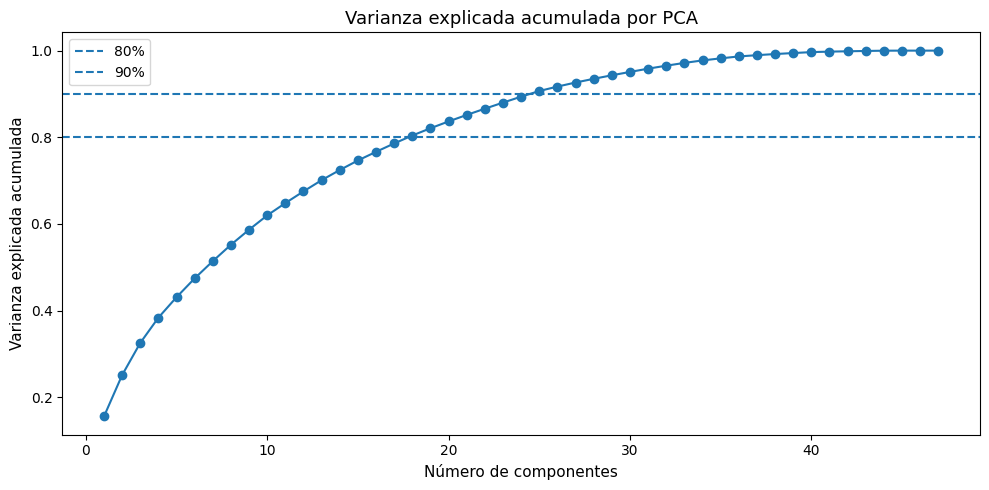

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(explained["component"], explained["cumulative_variance"], marker="o")
ax.axhline(0.80, linestyle="--", label="80%")
ax.axhline(0.90, linestyle="--", label="90%")
ax.set_title("Varianza explicada acumulada por PCA")
ax.set_xlabel("Número de componentes")
ax.set_ylabel("Varianza explicada acumulada")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretación MLOps

El análisis PCA se utilizó para evaluar si las variables numéricas construidas pueden resumirse en un número menor de dimensiones sin perder demasiada información. Después de remover variables con baja varianza y alta correlación, se aplicó PCA sobre la matriz reducida.

Los resultados muestran que se requieren 18 componentes principales para explicar aproximadamente el 80% de la varianza y 25 componentes para explicar aproximadamente el 90%. Esto indica que la estructura de los datos no está dominada por una sola variable ni por un número muy pequeño de factores. Existen múltiples dimensiones relevantes para el monitoreo, incluyendo precio, cantidad, revenue, margen, elasticidad, soporte estadístico, frecuencia, composición y posición histórica del output.

El aumento en el número de componentes respecto a versiones previas es consistente con la incorporación de nuevas señales de estabilidad del output, como la posición de la recomendación frente a la banda histórica P20–P85 y la distancia respecto a P50. Estas variables agregan información adicional para monitoreo, sin modificar la lógica de recomendación.

Desde una perspectiva MLOps, este resultado confirma que el sistema no debe monitorearse con una sola métrica global. Reducir el monitoreo únicamente a precio promedio, revenue o cantidad podría ocultar cambios relevantes en segmentos específicos. Por ello, el semáforo MLOps debe combinar señales de datos, output, catálogos, soporte estadístico e impacto económico.

Aunque PCA es útil para entender la estructura y redundancia de las variables, no se recomienda reemplazar las variables originales por componentes principales en operación. Los componentes pierden interpretabilidad directa para negocio, auditoría y gobernanza. En este proyecto, PCA se usa como herramienta diagnóstica y exploratoria, no como sustituto de las variables monitoreables.

## 14. Análisis de sesgo por segmento

En este contexto, sesgo se entiende como desbalance o riesgo de representación insuficiente por producto, región, segmento, margen o disponibilidad de datos.

Esto es crítico porque el sistema puede funcionar bien a nivel global, pero presentar riesgo en segmentos específicos con bajo historial, alto revenue, alta incertidumbre de elasticidad o márgenes comprimidos.

In [43]:
bias_group_cols = ["vpareadescription", "distysegment"]
if BUSINESS_GROUP_COL in input_fe.columns:
    bias_group_cols.append(BUSINESS_GROUP_COL)
if PARENT_COL in input_fe.columns:
    # Para no generar una tabla demasiado granular, parent se resume en una tabla aparte.
    pass

segment_bias = input_fe.groupby(bias_group_cols, dropna=False).agg(
    n_transactions=("rslpriceusd", "size"),
    revenue_sum=("revenue", "sum"),
    median_resale_price=("rslpriceusd", "median"),
    median_into_stock_price=("into_stock_price", "median"),
    median_quantity=("quantity", "median"),
    auth_cost_match_rate=("into_stock_matches_auth_cost", "mean"),
    distributor_margin_pct_median=("distributor_margin_pct", "median"),
    channel_margin_share_median=("channel_margin_share", "median"),
    negative_distributor_margin_rate=("negative_distributor_margin_flag", "mean"),
    elasticity_hdi_width_median=("elasticity_hdi_width", "median"),
    n_kpn=("kpn", "nunique"),
    n_distributor_parents=(PARENT_COL, "nunique") if PARENT_COL in input_fe.columns else ("kpn", "nunique")
).reset_index()

segment_bias["transaction_share"] = segment_bias["n_transactions"] / segment_bias["n_transactions"].sum()
segment_bias["revenue_share"] = segment_bias["revenue_sum"] / segment_bias["revenue_sum"].sum()

segment_bias.sort_values("revenue_share", ascending=False).round(4).head(20)

,vpareadescription,distysegment,custombusinessgroup,n_transactions,revenue_sum,median_resale_price,median_into_stock_price,median_quantity,auth_cost_match_rate,distributor_margin_pct_median,channel_margin_share_median,negative_distributor_margin_rate,elasticity_hdi_width_median,n_kpn,n_distributor_parents,transaction_share,revenue_share
10,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000001,110652,1.066758e+10,0.0908,0.0741,144000.0,0.9985,0.1794,0.7035,0.0,1.1093,2614,5,0.4722,0.3703
5,VPAREA_00000001,DISTSEG_00000002,BUSINESSGRP_00000001,72184,5.640613e+09,0.1104,0.0888,120000.0,0.9963,0.1544,0.7497,0.0,1.1283,2752,8,0.3080,0.1958
9,VPAREA_00000001,DISTSEG_00000002,BUSINESSGRP_00000005,12957,4.721581e+09,6.5064,5.6400,18000.0,0.8993,0.1412,0.7946,0.0,2.1576,858,7,0.0553,0.1639
14,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000005,11082,3.683066e+09,5.4574,4.5530,24000.0,0.9650,0.1651,0.7356,0.0,1.8506,615,5,0.0473,0.1278
12,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000003,3790,1.388105e+09,0.6314,0.5291,48000.0,0.9187,0.1428,0.7225,0.0,1.1860,227,6,0.0162,0.0482
11,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000002,16332,1.285981e+09,1.1005,0.8139,24000.0,0.9938,0.2130,0.6532,0.0,1.7846,674,5,0.0697,0.0446
13,VPAREA_00000002,DISTSEG_00000002,BUSINESSGRP_00000004,1252,5.123063e+08,7.9939,7.0185,13680.0,0.8299,0.1569,0.7533,0.0,1.4480,139,5,0.0053,0.0178
6,VPAREA_00000001,DISTSEG_00000002,BUSINESSGRP_00000002,3174,2.894062e+08,1.7802,1.5552,20400.0,0.9899,0.1490,0.7681,0.0,2.1493,167,5,0.0135,0.0100
7,VPAREA_00000001,DISTSEG_00000002,BUSINESSGRP_00000003,1058,2.140593e+08,0.7800,0.5520,48000.0,0.9546,0.1502,0.7378,0.0,1.4169,99,4,0.0045,0.0074
8,VPAREA_00000001,DISTSEG_00000002,BUSINESSGRP_00000004,601,1.480610e+08,4.9200,4.0704,10800.0,0.9750,0.1747,0.7018,0.0,0.9237,55,4,0.0026,0.0051


### Interpretación MLOps

El análisis de sesgo por segmento permite identificar diferencias de representación y riesgo operativo entre combinaciones de región, segmento y grupo de negocio. En este contexto, el sesgo no se interpreta como una decisión comercial, sino como una señal de cobertura, concentración e incertidumbre.

Los resultados muestran que una parte importante del volumen transaccional y del revenue se concentra en pocos segmentos. Por ejemplo, algunos grupos tienen una participación elevada tanto en número de transacciones como en revenue, mientras que otros tienen baja representación pero pueden presentar precios medianos más altos, menor número de KPNs o mayor incertidumbre en elasticidad.

Desde una perspectiva MLOps, los segmentos con alto revenue y alta incertidumbre requieren mayor atención, porque un cambio pequeño en su comportamiento puede tener impacto relevante en el negocio. Por otro lado, segmentos con bajo número de transacciones o pocos KPNs pueden presentar mayor riesgo de inestabilidad estadística.

También se observa que la tasa de coincidencia entre precio/costo autorizado es alta en la mayoría de los segmentos, aunque algunos grupos presentan valores menores. Esto puede usarse como señal de calidad o cobertura del input, no como conclusión automática sobre desempeño del modelo.

La variable `elasticity_hdi_width_median` permite observar incertidumbre asociada a la elasticidad. Segmentos con mayor amplitud pueden requerir monitoreo adicional, ya que la recomendación podría estar respaldada por una señal estadística menos precisa.

En conjunto, esta sección ayuda a priorizar monitoreo por segmento: no todos los segmentos tienen el mismo peso, la misma cobertura ni el mismo nivel de incertidumbre. Por ello, el semáforo MLOps debe considerar tanto señales estadísticas como impacto de negocio agregado.

In [44]:
kpn_concentration = input_fe.groupby("kpn", dropna=False).agg(
    n_transactions=("rslpriceusd", "size"),
    revenue_sum=("revenue", "sum"),
    elasticity_hdi_width_median=("elasticity_hdi_width", "median")
).reset_index().sort_values("revenue_sum", ascending=False)

kpn_concentration["revenue_share"] = kpn_concentration["revenue_sum"] / kpn_concentration["revenue_sum"].sum()
kpn_concentration["cumulative_revenue_share"] = kpn_concentration["revenue_share"].cumsum()

print("Participación acumulada de revenue por top KPNs:")
for n in [10, 50, 100, 500, 1000]:
    if len(kpn_concentration) >= n:
        print(f"Top {n}: {kpn_concentration['cumulative_revenue_share'].iloc[n-1]*100:.2f}%")

kpn_concentration.head(10)

Participación acumulada de revenue por top KPNs:
Top 10: 12.87%
Top 50: 26.86%
Top 100: 35.92%
Top 500: 64.70%
Top 1000: 78.86%


,kpn,n_transactions,revenue_sum,elasticity_hdi_width_median,revenue_share,cumulative_revenue_share
6701,KPN_00006702,135,7.051498e+08,2.280014,0.024475,0.024475
4543,KPN_00004544,682,6.332806e+08,1.223920,0.021980,0.046455
3912,KPN_00003913,119,5.004838e+08,12.161538,0.017371,0.063827
6634,KPN_00006635,144,4.049299e+08,1.497811,0.014055,0.077881
6687,KPN_00006688,169,3.573819e+08,1.367358,0.012404,0.090286
793,KPN_00000794,329,3.232394e+08,1.679214,0.011219,0.101505
4149,KPN_00004150,212,2.141823e+08,2.322725,0.007434,0.108939
6029,KPN_00006030,436,2.030405e+08,1.153101,0.007047,0.115986
948,KPN_00000949,5328,1.983584e+08,1.761000,0.006885,0.122871
710,KPN_00000711,18,1.692013e+08,3.566008,0.005873,0.128744


### Interpretación MLOps: concentración por KPN

El análisis de concentración por KPN permite identificar qué proporción del revenue total está asociada a los productos con mayor peso económico. Esto es relevante porque el monitoreo MLOps no debe tratar todos los productos con la misma prioridad operativa.

Los resultados muestran que los primeros 10 KPNs concentran aproximadamente 12.87% del revenue, los primeros 100 concentran 35.92% y los primeros 1,000 concentran 78.86%. Esto indica una concentración relevante del impacto económico en una fracción limitada de productos.

Desde una perspectiva MLOps, esta concentración justifica aplicar métricas ponderadas por revenue dentro del semáforo. Un cambio pequeño en precio, cantidad, margen o incertidumbre dentro de un KPN de alto revenue puede tener mayor impacto operativo que un cambio grande en un KPN con bajo volumen económico.

También se observa que algunos KPNs de alto revenue tienen relativamente pocas transacciones o mayor amplitud de incertidumbre en elasticidad. Estos casos deben monitorearse con especial cuidado, ya que combinan alto impacto económico con posible fragilidad estadística.



### Justificación

El análisis de sesgo permite decidir dónde aplicar mayor atención operativa. Para el semáforo MLOps no conviene tratar todos los cambios igual: un drift pequeño en un segmento con alto revenue o margen crítico puede ser más importante que un drift grande en un segmento marginal.

## 15. Relación con drift y semáforo

Las features generadas alimentan el sistema de monitoreo MLOps. La tabla siguiente propone señales candidatas para drift y semáforo, manteniendo el motor de pricing como caja negra.


In [45]:
drift_feature_catalog = pd.DataFrame([
    {
        "feature": "log_into_stock_price",
        "type": "input/model_auth",
        "metric": "PSI / KS",
        "business_reason": "Variable de precio usada para monitorear estabilidad demanda-precio",
        "green": "PSI < 0.10",
        "yellow": "0.10 <= PSI <= 0.25",
        "red": "PSI > 0.25",
        "primary_action": "Review/recalibrate/retrain if persistent"
    },
    {
        "feature": "log_quantity",
        "type": "input/model_auth",
        "metric": "PSI / KS",
        "business_reason": "Variable de cantidad usada para monitorear estabilidad demanda-precio",
        "green": "PSI < 0.10",
        "yellow": "0.10 <= PSI <= 0.25",
        "red": "PSI > 0.25",
        "primary_action": "Review/recalibrate/retrain if persistent"
    },
    {
        "feature": "mean_elasticity",
        "type": "model_output",
        "metric": "KS",
        "business_reason": "Cambio en sensibilidad estimada por el sistema de recomendación",
        "green": "KS < 0.05",
        "yellow": "0.05 <= KS <= 0.15",
        "red": "KS > 0.15",
        "primary_action": "Review model stability"
    },
    {
        "feature": "s_curve_price_range_p85_p20",
        "type": "output",
        "metric": "KS / cambio relativo",
        "business_reason": "Detecta compresión o expansión del rango histórico de precios usado por el sistema",
        "green": "Cambio bajo",
        "yellow": "Revisión de estabilidad del output",
        "red": "Compresión o expansión crítica",
        "primary_action": "Review recommendation stability"
    },
    {
        "feature": "P20_Was_Adjusted",
        "type": "output/control_signal",
        "metric": "Z-test de proporciones",
        "business_reason": "Aumento en señales de ajuste del output puede indicar cambios en estructura de costos, márgenes o composición de datos",
        "green": "z <= 2.0",
        "yellow": "2.0 < z <= 3.5",
        "red": "z > 3.5",
        "primary_action": "Review control signals and data behavior"
    },
    {
        "feature": "order_size_bin_distribution",
        "type": "business_artifact_catalog",
        "metric": "PSI categórico / cambio de proporciones",
        "business_reason": "Detecta cambios en composición de tamaño de orden del canal",
        "green": "Cambios dentro de tolerancia",
        "yellow": "Revisión de mix de órdenes",
        "red": "Revisar catálogo o comportamiento operativo",
        "primary_action": "Review catalog coverage; not automatic model retraining"
    },
    {
        "feature": "disty_margin_original_bin_distribution",
        "type": "business_artifact_catalog",
        "metric": "PSI categórico / cambio de proporciones",
        "business_reason": "Detecta cambios en estructura agregada de margen del canal",
        "green": "Cambios dentro de tolerancia",
        "yellow": "Revisión de composición de margen",
        "red": "Revisar catálogo o comportamiento operativo",
        "primary_action": "Review business artifact; not automatic model retraining"
    },
    {
        "feature": "channel_margin_share_bin_distribution",
        "type": "business_artifact_catalog",
        "metric": "PSI categórico / cambio de proporciones",
        "business_reason": "Detecta cambios en la distribución relativa del margen dentro del canal",
        "green": "Cambios dentro de tolerancia",
        "yellow": "Revisión de composición del canal",
        "red": "Revisar catálogo o comportamiento operativo",
        "primary_action": "Review channel behavior; not automatic model retraining"
    },
    {
        "feature": "recommended_outside_p20_p85 / recommended_historical_zone",
        "type": "output/control_signal",
        "metric": "Cambio de proporciones / PSI categórico",
        "business_reason": "Detecta cambios en la posición de la recomendación frente a la banda histórica P20-P85",
        "green": "Cambio dentro de línea base",
        "yellow": "Aumento moderado o cambio de zona",
        "red": "Aumento persistente o material fuera de banda",
        "primary_action": "Review output stability; not automatic retraining"
    },
])

drift_feature_catalog

,feature,type,metric,business_reason,green,yellow,red,primary_action
0,log_into_stock_price,input/model_auth,PSI / KS,Variable de precio usada para monitorear estab...,PSI < 0.10,0.10 <= PSI <= 0.25,PSI > 0.25,Review/recalibrate/retrain if persistent
1,log_quantity,input/model_auth,PSI / KS,Variable de cantidad usada para monitorear est...,PSI < 0.10,0.10 <= PSI <= 0.25,PSI > 0.25,Review/recalibrate/retrain if persistent
2,mean_elasticity,model_output,KS,Cambio en sensibilidad estimada por el sistema...,KS < 0.05,0.05 <= KS <= 0.15,KS > 0.15,Review model stability
3,s_curve_price_range_p85_p20,output,KS / cambio relativo,Detecta compresión o expansión del rango histó...,Cambio bajo,Revisión de estabilidad del output,Compresión o expansión crítica,Review recommendation stability
4,P20_Was_Adjusted,output/control_signal,Z-test de proporciones,Aumento en señales de ajuste del output puede ...,z <= 2.0,2.0 < z <= 3.5,z > 3.5,Review control signals and data behavior
5,order_size_bin_distribution,business_artifact_catalog,PSI categórico / cambio de proporciones,Detecta cambios en composición de tamaño de or...,Cambios dentro de tolerancia,Revisión de mix de órdenes,Revisar catálogo o comportamiento operativo,Review catalog coverage; not automatic model r...
6,disty_margin_original_bin_distribution,business_artifact_catalog,PSI categórico / cambio de proporciones,Detecta cambios en estructura agregada de marg...,Cambios dentro de tolerancia,Revisión de composición de margen,Revisar catálogo o comportamiento operativo,Review business artifact; not automatic model ...
7,channel_margin_share_bin_distribution,business_artifact_catalog,PSI categórico / cambio de proporciones,Detecta cambios en la distribución relativa de...,Cambios dentro de tolerancia,Revisión de composición del canal,Revisar catálogo o comportamiento operativo,Review channel behavior; not automatic model r...
8,recommended_outside_p20_p85 / recommended_hist...,output/control_signal,Cambio de proporciones / PSI categórico,Detecta cambios en la posición de la recomenda...,Cambio dentro de línea base,Aumento moderado o cambio de zona,Aumento persistente o material fuera de banda,Review output stability; not automatic retraining


### Interpretación MLOps

La tabla de señales candidatas conecta las variables generadas en el notebook con posibles mecanismos de monitoreo, drift y semáforo. El objetivo no es automatizar decisiones comerciales ni documentar la lógica interna del motor de pricing, sino definir qué señales deben observarse para evaluar estabilidad, cobertura y calidad del sistema.

Las variables de entrada, como precio y cantidad en escala logarítmica, permiten monitorear si la población asociada al modelo mantiene una relación comparable con la línea base histórica. Cambios persistentes en estas variables pueden indicar drift de datos y justificar revisión, recalibración o reentrenamiento.

Las variables de salida, como elasticidad estimada, rangos de percentiles o señales de ajuste, permiten evaluar la estabilidad del output generado por el sistema. Estas señales no recalculan recomendaciones; únicamente ayudan a detectar cambios relevantes en dispersión, sensibilidad, soporte estadístico o condiciones de control.

Los catálogos de bins se monitorean como artefactos MLOps. Un cambio en la distribución de tamaños de orden, margen o participación relativa del margen no implica automáticamente que el modelo deba reentrenarse. Puede indicar cambio de mezcla, cambio operativo del canal, necesidad de recalcular cortes o revisión con stakeholders.

El semáforo propuesto separa acciones: algunas alertas sugieren revisión del modelo, mientras que otras sugieren revisión de catálogos, calidad de datos o comportamiento operativo. Esta separación evita tratar todos los cambios como problemas del modelo y permite una gobernanza más precisa.

## 16. Dataset final de características

Se exporta una primera versión de la tabla de características para pruebas de contrato, drift baseline, semáforo o documentación MLOps.

Los catálogos se exportan como artefactos versionables. Su objetivo en esta entrega es demostrar trazabilidad y monitoreo, no documentar reglas comerciales propietarias.


In [46]:
EXPORT_PATH = os.path.join(DIR_PATH, "avance2_feature_table_equipo46_v6_mlops_sanitized.csv")
ORDER_CATALOG_PATH = os.path.join(DIR_PATH, "avance2_order_size_catalog_equipo46_v6_mlops_sanitized.csv")
DISTY_MARGIN_CATALOG_PATH = os.path.join(DIR_PATH, "avance2_disty_margin_catalog_equipo46_v6_mlops_sanitized.csv")
CHANNEL_MARGIN_CATALOG_PATH = os.path.join(DIR_PATH, "avance2_channel_margin_catalog_equipo46_v6_mlops_sanitized.csv")
CATALOG_METADATA_PATH = os.path.join(DIR_PATH, "avance2_catalog_metadata_equipo46_v6_mlops_sanitized.csv")

feature_table_export = feature_table.copy()
for c in feature_table_export.select_dtypes(include=["datetime64[ns]"]).columns:
    feature_table_export[c] = feature_table_export[c].astype(str)

feature_table_export.to_csv(EXPORT_PATH, index=False)
order_size_catalog.to_csv(ORDER_CATALOG_PATH, index=False)
disty_margin_catalog.to_csv(DISTY_MARGIN_CATALOG_PATH, index=False)
channel_margin_catalog.to_csv(CHANNEL_MARGIN_CATALOG_PATH, index=False)
catalog_metadata.to_csv(CATALOG_METADATA_PATH, index=False)

print(f"Feature table exportada: {EXPORT_PATH}")
print(f"Dimensión feature table: {feature_table_export.shape[0]:,} filas x {feature_table_export.shape[1]:,} columnas")
print(f"Order size catalog: {ORDER_CATALOG_PATH}")
print(f"Disty margin catalog: {DISTY_MARGIN_CATALOG_PATH}")
print(f"Channel margin catalog: {CHANNEL_MARGIN_CATALOG_PATH}")
print(f"Catalog metadata: {CATALOG_METADATA_PATH}")


Feature table exportada: /content/drive/MyDrive/Maestria/Yageo-MLOPS/avance2_feature_table_equipo46_v6_mlops_sanitized.csv
Dimensión feature table: 8,314 filas x 104 columnas
Order size catalog: /content/drive/MyDrive/Maestria/Yageo-MLOPS/avance2_order_size_catalog_equipo46_v6_mlops_sanitized.csv
Disty margin catalog: /content/drive/MyDrive/Maestria/Yageo-MLOPS/avance2_disty_margin_catalog_equipo46_v6_mlops_sanitized.csv
Channel margin catalog: /content/drive/MyDrive/Maestria/Yageo-MLOPS/avance2_channel_margin_catalog_equipo46_v6_mlops_sanitized.csv
Catalog metadata: /content/drive/MyDrive/Maestria/Yageo-MLOPS/avance2_catalog_metadata_equipo46_v6_mlops_sanitized.csv


## 17. Conclusiones en contexto CRISP-ML(Q)

## Principales hallazgos del análisis y uso MLOps

A partir de la ingeniería de características se identificaron varios hallazgos relevantes para el diseño del monitoreo MLOps:

1. **Los catálogos de bins funcionan como línea base de composición del canal.**  
   Los bins de tamaño de orden, margen del distribuidor y participación relativa del margen permiten observar cómo se distribuyen las transacciones dentro de grupos comparables.  
   En futuras etapas, estas distribuciones podrán usarse como baseline para detectar drift categórico mediante PSI categórico, cambios de proporciones o aumento de registros en categoría `Missing`.

2. **La cobertura entre catálogos generales y datos autorizados es una señal crítica.**  
   Al asignar los registros autorizados a los catálogos construidos con datos generales, se observaron diferencias de cobertura, especialmente en algunas categorías con valores `Missing`.  
   Esto es importante porque un aumento de `Missing` en producción podría indicar que el modelo está recibiendo combinaciones de producto, región o segmento no suficientemente representadas en los catálogos base. En MLOps, esta señal se usaría para revisar cobertura de catálogos, granularidad o ventanas históricas, no necesariamente para reentrenar el modelo de forma automática.

3. **El output del modelo muestra alta estabilidad en varias señales de precio.**  
   Las validaciones de monotonicidad de percentiles de precio y cantidad se cumplieron en todos los registros analizados. Esto permite usar estas variables como pruebas de calidad del output: si en una futura corrida se rompe la monotonicidad, se puede activar una alerta de calidad del pipeline.

4. **La tasa de ajustes del output es baja, pero útil como señal de control.**  
   La variable `P20_Was_Adjusted` presentó una tasa baja de activación. Esto sugiere que, en la corrida actual, la mayoría de los registros no requirieron ajuste por esta condición de control.  
   En monitoreo futuro, un incremento persistente en esta tasa podría indicar cambios en costos, márgenes, composición de datos o condiciones del canal. Por ello, esta variable se conservará como señal candidata para el semáforo MLOps.

5. **El soporte estadístico de algunas recomendaciones requiere atención.**  
   La variable `q0_low_support_flag` mostró que una proporción relevante de registros tiene bajo soporte local. Esto no implica error, pero sí indica que algunas recomendaciones pueden depender de menor evidencia histórica.  
   En MLOps, esta señal puede usarse para priorizar revisión humana, ponderar alertas o distinguir entre recomendaciones robustas y recomendaciones con menor soporte de datos.

6. **La concentración de revenue por segmento y KPN confirma que no todos los cambios deben pesar igual.**  
   El análisis de sesgo mostró que ciertos segmentos y productos concentran una proporción importante del revenue. Por ello, el semáforo MLOps no debe evaluar únicamente el tamaño estadístico del drift, sino también el impacto económico del segmento afectado.  
   Un drift moderado en un segmento de alto revenue puede ser más relevante que un drift alto en un segmento marginal.

7. **La selección de características permitió distinguir variables de control, variables redundantes y variables candidatas para monitoreo.**  
   Algunas variables fueron constantes o casi constantes, como las validaciones de monotonicidad. Aunque no aportan para PCA o análisis de varianza, son útiles como controles de calidad.  
   Otras variables altamente correlacionadas, como percentiles de precio o escenarios de recomendación, ayudan a entender redundancia y evitar complejidad innecesaria en análisis técnicos.

8. **PCA mostró que el monitoreo no debe depender de una sola métrica.**  
   El análisis de componentes principales indicó que se requieren varias dimensiones para explicar una parte significativa de la varianza. Esto confirma que el sistema debe monitorearse con múltiples señales: precio, cantidad, revenue, márgenes, elasticidad, soporte estadístico, composición de bins y concentración por segmento.

Con base en estos hallazgos, la tabla final de características se utilizará como insumo para etapas posteriores de MLOps, principalmente:

- construir un baseline de drift;
- comparar corridas futuras contra la línea base;
- monitorear cambios de distribución en precio, cantidad, márgenes y bins;
- evaluar cobertura y aparición de categorías `Missing`;
- ponderar alertas por revenue y soporte transaccional;
- alimentar un semáforo MLOps con señales estadísticas y de negocio;
- documentar trazabilidad de catálogos y variables usadas en monitoreo.

En esta entrega no se definen thresholds productivos definitivos. Los umbrales del semáforo deberán calibrarse posteriormente usando ventanas históricas, comparación baseline-current, impacto económico y validación con stakeholders. El valor de esta fase consiste en haber identificado y preparado las variables candidatas que permitirán construir ese monitoreo de forma trazable, auditable y alineada con CRISP-ML(Q).